# Logistic Scorecard — V1

This notebook develops a credit risk scorecard using logistic regression with Weight of Evidence (WoE)-transformed features.

### Validation Principles

- Binning, imputation, and encoding rules are learned exclusively from the training set.
- The validation set guides model-selection decisions.
- The test set is reserved for final evaluation.
- Temporal variables and identifiers are excluded from the predictor set.


In [1]:
# ============================================================
# 1. INITIALISATION
# ============================================================

from pathlib import Path
import warnings
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
     average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROJECT_DIR = Path.cwd().parent
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

for directory in [
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "default_flag"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

print(f"Projet : {PROJECT_DIR}")
print(f"Données : {DATA_PROCESSED_DIR}")


Projet : /Users/kwamekristianlaban/Documents/Projet_perso/P2
Données : /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed


## Data Loading and Scope

The time-based partitions created in the data-preparation notebook are reloaded without modification. The training set is the only partition used to learn transformations; the validation and test sets are used solely to assess temporal generalisation.


In [2]:
# ============================================================
# 2. CHARGEMENT DES PARTITIONS
# ============================================================

TRAIN_FILE = DATA_PROCESSED_DIR / "train_v1.parquet"
VALIDATION_FILE = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_FILE = DATA_PROCESSED_DIR / "test_v1.parquet"

train_df = pd.read_parquet(TRAIN_FILE)
validation_df = pd.read_parquet(VALIDATION_FILE)
test_df = pd.read_parquet(TEST_FILE)

for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    assert TARGET in dataframe.columns, (
        f"La cible '{TARGET}' est absente de {split_name}."
    )

    print(
        f"{split_name:<10} | "
        f"{len(dataframe):>7,} prêts | "
        f"taux de défaut : {dataframe[TARGET].mean():.2%}"
    )


Train      | 172,988 prêts | taux de défaut : 12.43%
Validation | 162,570 prêts | taux de défaut : 13.73%
Test       | 283,026 prêts | taux de défaut : 14.89%


In [3]:
#Variable V1
# ============================================================
# 3. DÉFINITION DES VARIABLES DE LA SCORECARD V1
# ============================================================

NUMERIC_FEATURES = [
    "fico_score",
    "dti",
    "revol_util",
    "loan_amnt",
    "annual_inc",
    "credit_history_months",
]

CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
]

FEATURES_V1 = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Variables non admissibles comme prédicteurs dans cette V1.
EXCLUDED_FEATURES = [
    TARGET,
    "issue_d",
    "issue_year",
]

for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():
    missing_features = sorted(
        set(FEATURES_V1) - set(dataframe.columns)
    )

    assert not missing_features, (
        f"Variables absentes de {split_name} : "
        f"{missing_features}"
    )

print("Variables numériques :", NUMERIC_FEATURES)
print("Variables catégorielles :", CATEGORICAL_FEATURES)
print(f"Nombre total de variables V1 : {len(FEATURES_V1)}")


Variables numériques : ['fico_score', 'dti', 'revol_util', 'loan_amnt', 'annual_inc', 'credit_history_months']
Variables catégorielles : ['home_ownership', 'purpose', 'verification_status']
Nombre total de variables V1 : 9


In [4]:
#Jeux X et Y
# ============================================================
# 4. SÉPARATION PRÉDICTEURS / CIBLE
# ============================================================

X_train = train_df.loc[:, FEATURES_V1].copy()
y_train = train_df[TARGET].astype("int8").copy()

X_validation = validation_df.loc[:, FEATURES_V1].copy()
y_validation = validation_df[TARGET].astype("int8").copy()

X_test = test_df.loc[:, FEATURES_V1].copy()
y_test = test_df[TARGET].astype("int8").copy()

dataset_overview = pd.DataFrame(
    [
        {
            "split": "Train",
            "n_loans": len(X_train),
            "n_defaults": int(y_train.sum()),
            "default_rate": y_train.mean(),
        },
        {
            "split": "Validation",
            "n_loans": len(X_validation),
            "n_defaults": int(y_validation.sum()),
            "default_rate": y_validation.mean(),
        },
        {
            "split": "Test",
            "n_loans": len(X_test),
            "n_defaults": int(y_test.sum()),
            "default_rate": y_test.mean(),
        },
    ]
)

display(dataset_overview)


,split,n_loans,n_defaults,default_rate
0,Train,172988,21508,0.1243
1,Validation,162570,22315,0.1373
2,Test,283026,42132,0.1489


In [5]:
#Controle qualité
# ============================================================
# 5. CONTRÔLE DES VARIABLES AVANT TRANSFORMATION
# ============================================================

quality_rows = []

for feature in FEATURES_V1:
    for split_name, dataframe in {
        "Train": X_train,
        "Validation": X_validation,
        "Test": X_test,
    }.items():
        quality_rows.append(
            {
                "feature": feature,
                "feature_type": (
                    "Numérique"
                    if feature in NUMERIC_FEATURES
                    else "Catégorielle"
                ),
                "split": split_name,
                "missing_rate": dataframe[feature].isna().mean(),
                "n_unique": dataframe[feature].nunique(dropna=True),
            }
        )

feature_quality_summary = pd.DataFrame(quality_rows)

display(
    feature_quality_summary.sort_values(
        ["feature_type", "feature", "split"]
    )
)


,feature,feature_type,split,missing_rate,n_unique
20,home_ownership,Catégorielle,Test,0.0000,4
18,home_ownership,Catégorielle,Train,0.0000,4
19,home_ownership,Catégorielle,Validation,0.0000,4
23,purpose,Catégorielle,Test,0.0000,14
21,purpose,Catégorielle,Train,0.0000,14
22,purpose,Catégorielle,Validation,0.0000,13
26,verification_status,Catégorielle,Test,0.0000,3
24,verification_status,Catégorielle,Train,0.0000,3
25,verification_status,Catégorielle,Validation,0.0000,3
14,annual_inc,Numérique,Test,0.0000,19338


## Binning and Weight of Evidence Transformation

The scorecard uses logistic regression with Weight of Evidence (WoE)-transformed features. Each numerical feature is divided into five approximately equal-frequency bins, defined exclusively from the training set. Missing values are treated as an explicit category.

Categorical features are retained at the category level, except for rare categories—representing less than 1% of the training set—which are grouped into `Other`. Any category unseen in the validation or test sets is also mapped to `Other`.

WoE compares the proportion of non-defaults with the proportion of defaults within each bin. Information Value (IV) measures the univariate predictive strength of a feature; it does not replace multivariate model evaluation.


In [7]:
#Parametre et fonctions
# ============================================================
# 6. BINNING ET TRANSFORMATION WOE
# ============================================================

N_NUMERIC_BINS = 5
RARE_CATEGORY_THRESHOLD = 0.01
SMOOTHING = 0.5
MISSING_LABEL = "Missing"
OTHER_LABEL = "Other"

assert set(y_train.unique()).issubset({0, 1}), (
    "La cible doit être binaire : 0 = non-défaut, 1 = défaut."
)


def make_numeric_bucket(
    series: pd.Series,
    bin_edges: np.ndarray,
) -> pd.Series:
    """Transforme une variable numérique en libellés de classes."""
    buckets = pd.cut(
        series,
        bins=bin_edges,
        include_lowest=True,
        duplicates="drop",
    )

    return (
        buckets.astype("string")
        .fillna(MISSING_LABEL)
    )


def make_categorical_bucket(
    series: pd.Series,
    retained_categories: set[str],
) -> pd.Series:
    """Regroupe catégories rares, manquantes et inconnues."""
    values = (
        series.astype("string")
        .fillna(MISSING_LABEL)
    )

    return values.where(
        values.isin(retained_categories),
        OTHER_LABEL,
    )


def compute_woe_table(
    buckets: pd.Series,
    target: pd.Series,
    feature: str,
    smoothing: float = SMOOTHING,
) -> pd.DataFrame:
    """
    Calcule WOE et IV par classe.

    Convention :
    WOE = ln(part_non_defauts / part_defauts).
    Un WOE positif correspond donc à une classe relativement moins risquée.
    """
    woe_table = (
        pd.DataFrame(
            {
                "bucket": buckets.astype("string"),
                "target": target.astype("int8"),
            }
        )
        .groupby("bucket", dropna=False, observed=False)
        .agg(
            n_loans=("target", "size"),
            n_defaults=("target", "sum"),
        )
        .reset_index()
    )

    woe_table["n_non_defaults"] = (
        woe_table["n_loans"] - woe_table["n_defaults"]
    )

    n_buckets = len(woe_table)

    woe_table["dist_non_defaults"] = (
        woe_table["n_non_defaults"] + smoothing
    ) / (
        woe_table["n_non_defaults"].sum()
        + smoothing * n_buckets
    )

    woe_table["dist_defaults"] = (
        woe_table["n_defaults"] + smoothing
    ) / (
        woe_table["n_defaults"].sum()
        + smoothing * n_buckets
    )

    woe_table["woe"] = np.log(
        woe_table["dist_non_defaults"]
        / woe_table["dist_defaults"]
    )

    woe_table["iv_component"] = (
        woe_table["dist_non_defaults"]
        - woe_table["dist_defaults"]
    ) * woe_table["woe"]

    woe_table["default_rate"] = (
        woe_table["n_defaults"]
        / woe_table["n_loans"]
    )

    woe_table["feature"] = feature

    return woe_table[
        [
            "feature",
            "bucket",
            "n_loans",
            "n_non_defaults",
            "n_defaults",
            "default_rate",
            "dist_non_defaults",
            "dist_defaults",
            "woe",
            "iv_component",
        ]
    ]


In [8]:
# ============================================================
# APPRENTISSAGE DES RÈGLES WOE SUR LE TRAIN UNIQUEMENT
# ============================================================

woe_rules = {
    "numeric_edges": {},
    "categorical_retained_categories": {},
    "woe_mapping": {},
}

woe_detail_tables = []
iv_rows = []

# Variables numériques : bornes basées uniquement sur les quantiles du train.
for feature in NUMERIC_FEATURES:
    non_missing_values = X_train[feature].dropna()

    quantile_edges = np.unique(
        np.quantile(
            non_missing_values,
            q=np.linspace(0, 1, N_NUMERIC_BINS + 1),
        )
    )

    assert len(quantile_edges) >= 3, (
        f"Binning impossible pour {feature} : "
        "pas assez de valeurs distinctes."
    )

    quantile_edges[0] = -np.inf
    quantile_edges[-1] = np.inf

    train_buckets = make_numeric_bucket(
        series=X_train[feature],
        bin_edges=quantile_edges,
    )

    woe_table = compute_woe_table(
        buckets=train_buckets,
        target=y_train,
        feature=feature,
    )

    woe_rules["numeric_edges"][feature] = quantile_edges

    woe_rules["woe_mapping"][feature] = dict(
        zip(
            woe_table["bucket"],
            woe_table["woe"],
        )
    )

    woe_detail_tables.append(woe_table)

    iv_rows.append(
        {
            "feature": feature,
            "feature_type": "Numérique",
            "n_buckets": len(woe_table),
            "iv": woe_table["iv_component"].sum(),
        }
    )

# Variables catégorielles : catégories rares regroupées d'après le train.
for feature in CATEGORICAL_FEATURES:
    train_categories = (
        X_train[feature]
        .astype("string")
        .fillna(MISSING_LABEL)
    )

    category_share = train_categories.value_counts(
        normalize=True,
        dropna=False,
    )

    retained_categories = set(
        category_share.loc[
            category_share >= RARE_CATEGORY_THRESHOLD
        ].index.astype("string")
    )

    train_buckets = make_categorical_bucket(
        series=X_train[feature],
        retained_categories=retained_categories,
    )

    woe_table = compute_woe_table(
        buckets=train_buckets,
        target=y_train,
        feature=feature,
    )

    woe_rules[
        "categorical_retained_categories"
    ][feature] = retained_categories

    woe_rules["woe_mapping"][feature] = dict(
        zip(
            woe_table["bucket"],
            woe_table["woe"],
        )
    )

    woe_detail_tables.append(woe_table)

    iv_rows.append(
        {
            "feature": feature,
            "feature_type": "Catégorielle",
            "n_buckets": len(woe_table),
            "iv": woe_table["iv_component"].sum(),
        }
    )

woe_detail = pd.concat(
    woe_detail_tables,
    ignore_index=True,
)

iv_summary = (
    pd.DataFrame(iv_rows)
    .sort_values("iv", ascending=False)
    .reset_index(drop=True)
)

print("Règles WOE apprises sur le train.")
print("Variables numériques :", len(woe_rules["numeric_edges"]))
print(
    "Variables catégorielles :",
    len(woe_rules["categorical_retained_categories"]),
)

display(iv_summary)


Règles WOE apprises sur le train.
Variables numériques : 6
Variables catégorielles : 3


,feature,feature_type,n_buckets,iv
0,fico_score,Numérique,5,0.1310
1,annual_inc,Numérique,5,0.0867
2,dti,Numérique,5,0.0364
3,revol_util,Numérique,6,0.0338
4,purpose,Catégorielle,10,0.0311
5,home_ownership,Catégorielle,4,0.0294
6,credit_history_months,Numérique,5,0.0157
7,loan_amnt,Numérique,5,0.0044
8,verification_status,Catégorielle,3,0.0016


In [9]:
assert len(woe_rules["numeric_edges"]) == len(NUMERIC_FEATURES)
assert (
    len(woe_rules["categorical_retained_categories"])
    == len(CATEGORICAL_FEATURES)
)

assert len(woe_rules["woe_mapping"]) == len(FEATURES_V1)

print("Règles WOE complètes : prêt pour la transformation.")


Règles WOE complètes : prêt pour la transformation.


In [10]:
#Transformation des partitions
# ============================================================
# 8. APPLICATION DES RÈGLES WOE AUX TROIS PARTITIONS
# ============================================================

def transform_to_woe(
    dataframe: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
    rules: dict,
) -> pd.DataFrame:
    """
    Applique les règles WOE apprises exclusivement sur le train.

    Les classes absentes du train, y compris les valeurs manquantes apparues
    seulement en validation ou test, reçoivent un WOE neutre de 0.
    """
    transformed = pd.DataFrame(index=dataframe.index)

    for feature in numeric_features:
        buckets = make_numeric_bucket(
            series=dataframe[feature],
            bin_edges=rules["numeric_edges"][feature],
        )

        transformed[f"{feature}_woe"] = (
            buckets
            .map(rules["woe_mapping"][feature])
            .fillna(0.0)
            .astype(float)
        )

    for feature in categorical_features:
        buckets = make_categorical_bucket(
            series=dataframe[feature],
            retained_categories=rules[
                "categorical_retained_categories"
            ][feature],
        )

        fallback_woe = rules["woe_mapping"][feature].get(
            OTHER_LABEL,
            0.0,
        )

        transformed[f"{feature}_woe"] = (
            buckets
            .map(rules["woe_mapping"][feature])
            .fillna(fallback_woe)
            .astype(float)
        )

    return transformed



X_train_woe = transform_to_woe(
    X_train,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    woe_rules,
)

X_validation_woe = transform_to_woe(
    X_validation,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    woe_rules,
)

X_test_woe = transform_to_woe(
    X_test,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    woe_rules,
)

assert X_train_woe.isna().sum().sum() == 0
assert X_validation_woe.isna().sum().sum() == 0
assert X_test_woe.isna().sum().sum() == 0

print("Transformation WOE terminée sans valeur manquante.")


print("Dimensions après WOE :")
print("Train      :", X_train_woe.shape)
print("Validation :", X_validation_woe.shape)
print("Test       :", X_test_woe.shape)

display(X_train_woe.head())


Transformation WOE terminée sans valeur manquante.
Dimensions après WOE :
Train      : (172988, 9)
Validation : (162570, 9)
Test       : (283026, 9)


,fico_score_woe,dti_woe,revol_util_woe,loan_amnt_woe,annual_inc_woe,credit_history_months_woe,home_ownership_woe,purpose_woe,verification_status_woe
0,0.7400,-0.2740,-0.2207,-0.0263,-0.3882,0.1791,-0.1653,0.1877,-0.0510
1,0.7400,0.2632,-0.2207,-0.0263,-0.3882,-0.0732,-0.1653,-0.6798,0.0361
2,-0.0092,-0.1026,0.3333,-0.0385,-0.1512,0.1097,-0.1653,-0.2670,0.0168
3,0.7400,0.1625,0.3333,-0.0263,-0.3882,-0.1718,-0.1653,0.1321,0.0168
4,-0.4040,0.2632,-0.2207,-0.0263,-0.1512,-0.1718,-0.1653,0.3170,0.0168


In [11]:
#Lecture de l'iv
def interpret_iv(iv: float) -> str:
    """Interprétation indicative de l'Information Value."""
    if iv < 0.02:
        return "Très faible"
    if iv < 0.10:
        return "Faible"
    if iv < 0.30:
        return "Moyenne"
    if iv < 0.50:
        return "Forte"
    return "Très forte / à auditer"


iv_summary["interpretation_iv"] = iv_summary["iv"].apply(
    interpret_iv
)

display(iv_summary)


,feature,feature_type,n_buckets,iv,interpretation_iv
0,fico_score,Numérique,5,0.1310,Moyenne
1,annual_inc,Numérique,5,0.0867,Faible
2,dti,Numérique,5,0.0364,Faible
3,revol_util,Numérique,6,0.0338,Faible
4,purpose,Catégorielle,10,0.0311,Faible
5,home_ownership,Catégorielle,4,0.0294,Faible
6,credit_history_months,Numérique,5,0.0157,Très faible
7,loan_amnt,Numérique,5,0.0044,Très faible
8,verification_status,Catégorielle,3,0.0016,Très faible


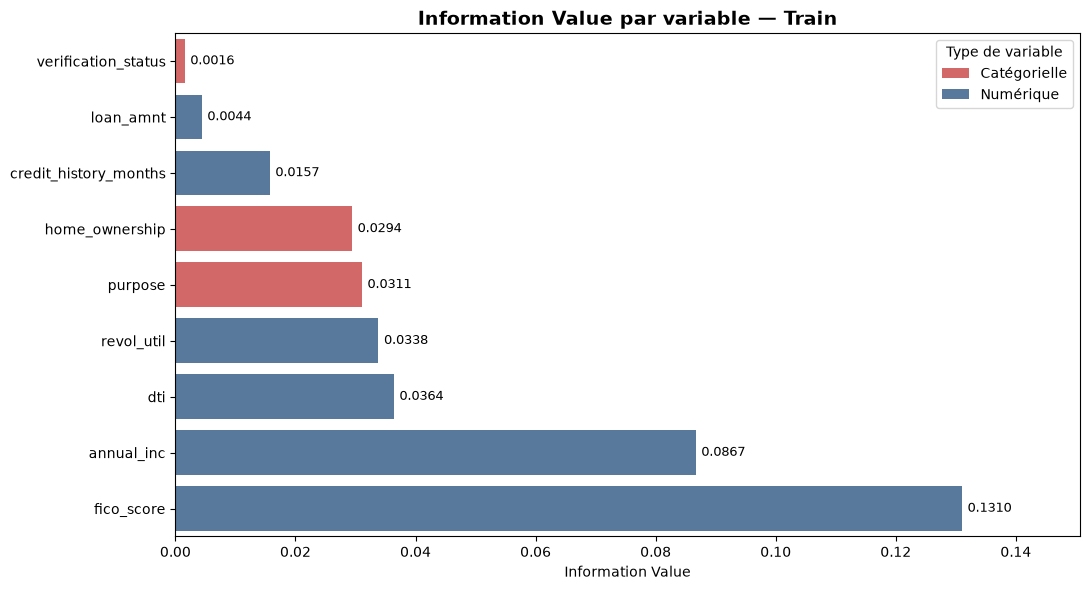

,feature,feature_type,n_buckets,iv,interpretation_iv
0,verification_status,Catégorielle,3,0.0016,Très faible
1,loan_amnt,Numérique,5,0.0044,Très faible
2,credit_history_months,Numérique,5,0.0157,Très faible
3,home_ownership,Catégorielle,4,0.0294,Faible
4,purpose,Catégorielle,10,0.0311,Faible
5,revol_util,Numérique,6,0.0338,Faible
6,dti,Numérique,5,0.0364,Faible
7,annual_inc,Numérique,5,0.0867,Faible
8,fico_score,Numérique,5,0.1310,Moyenne


In [12]:
# Copie et tri : garantit que chaque feature reste liée à son propre IV
iv_plot = (
    iv_summary
    .sort_values("iv", ascending=True)
    .reset_index(drop=True)
)

# Palette par type de variable
palette = {
    "Numérique": "#4C78A8",
    "Catégorielle": "#E45756"
}

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=iv_plot,
    x="iv",
    y="feature",
    hue="feature_type",
    palette=palette,
    dodge=False
)

plt.title("Information Value par variable — Train", fontsize=14, fontweight="bold")
plt.xlabel("Information Value")
plt.ylabel("")

# Affichage de la valeur IV exacte sur chaque barre
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=4,
        fontsize=9
    )

plt.xlim(0, iv_plot["iv"].max() * 1.15)
plt.legend(title="Type de variable", loc="upper right")
plt.tight_layout()
plt.show()

# Contrôle final : tableau dans exactement le même ordre que le graphique
display(iv_plot[["feature", "feature_type", "n_buckets", "iv", "interpretation_iv"]])


In [13]:
SEUIL_IV = 0.02

iv_selection = (
    iv_summary
    .query("iv >= @SEUIL_IV")
    .sort_values("iv", ascending=False)
    .reset_index(drop=True)
)

features_selectionnees = iv_selection["feature"].tolist()

print(f"Variables retenues (IV >= {SEUIL_IV:.2f}) :")
print(features_selectionnees)

display(iv_selection)


Variables retenues (IV >= 0.02) :
['fico_score', 'annual_inc', 'dti', 'revol_util', 'purpose', 'home_ownership']


,feature,feature_type,n_buckets,iv,interpretation_iv
0,fico_score,Numérique,5,0.1310,Moyenne
1,annual_inc,Numérique,5,0.0867,Faible
2,dti,Numérique,5,0.0364,Faible
3,revol_util,Numérique,6,0.0338,Faible
4,purpose,Catégorielle,10,0.0311,Faible
5,home_ownership,Catégorielle,4,0.0294,Faible


In [14]:
#export
iv_summary.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_iv_summary.csv",
    index=False,
)

woe_detail.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_woe_detail_train.csv",
    index=False,
)

print("Tables exportées :")
print("-", OUTPUT_TABLES_DIR / "scorecard_iv_summary.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_woe_detail_train.csv")


Tables exportées :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_iv_summary.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_woe_detail_train.csv


In [15]:
# Variables retenues, avec leur nom après la transformation WoE
features_selectionnees_woe = [
    f"{feature}_woe"
    for feature in features_selectionnees
]

# Vérification avant la modélisation
colonnes_manquantes = (
    set(features_selectionnees_woe)
    - set(X_train_woe.columns)
)

assert not colonnes_manquantes, (
    f"Colonnes WoE absentes : {colonnes_manquantes}"
)

# Jeux de données pour le modèle
X_train_model = X_train_woe[features_selectionnees_woe].copy()
X_validation_model = X_validation_woe[features_selectionnees_woe].copy()
X_test_model = X_test_woe[features_selectionnees_woe].copy()

# Entraînement
modele_logit_woe = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

modele_logit_woe.fit(X_train_model, y_train)

# Prédictions
proba_train = modele_logit_woe.predict_proba(X_train_model)[:, 1]
proba_validation = modele_logit_woe.predict_proba(X_validation_model)[:, 1]
proba_test = modele_logit_woe.predict_proba(X_test_model)[:, 1]

# Métriques de discrimination
auc_train = roc_auc_score(y_train, proba_train)
auc_validation = roc_auc_score(y_validation, proba_validation)
auc_test = roc_auc_score(y_test, proba_test)

gini_train = 2 * auc_train - 1
gini_validation = 2 * auc_validation - 1
gini_test = 2 * auc_test - 1

performance_modele = pd.DataFrame({
    "échantillon": ["Train", "Validation", "Test"],
    "AUC": [auc_train, auc_validation, auc_test],
    "Gini": [gini_train, gini_validation, gini_test],
})

display(performance_modele.round(4))


,échantillon,AUC,Gini
0,Train,0.6389,0.2778
1,Validation,0.6318,0.2636
2,Test,0.6300,0.2600


In [16]:
# ============================================================
# AUC PRECISION-RECALL — TRAIN / VALIDATION / TEST
# ============================================================

auc_pr_train = average_precision_score(
    y_train,
    proba_train,
)

auc_pr_validation = average_precision_score(
    y_validation,
    proba_validation,
)

auc_pr_test = average_precision_score(
    y_test,
    proba_test,
)

performance_auc_pr = pd.DataFrame({
    "échantillon": ["Train", "Validation", "Test"],
    "AUC_PR": [
        auc_pr_train,
        auc_pr_validation,
        auc_pr_test,
    ],
    "référence_aléatoire": [
        y_train.mean(),
        y_validation.mean(),
        y_test.mean(),
    ],
    "lift_vs_aléatoire": [
        auc_pr_train / y_train.mean(),
        auc_pr_validation / y_validation.mean(),
        auc_pr_test / y_test.mean(),
    ],
})

display(performance_auc_pr.round(4))


,échantillon,AUC_PR,référence_aléatoire,lift_vs_aléatoire
0,Train,0.1888,0.1243,1.5188
1,Validation,0.1997,0.1373,1.4545
2,Test,0.2126,0.1489,1.4279


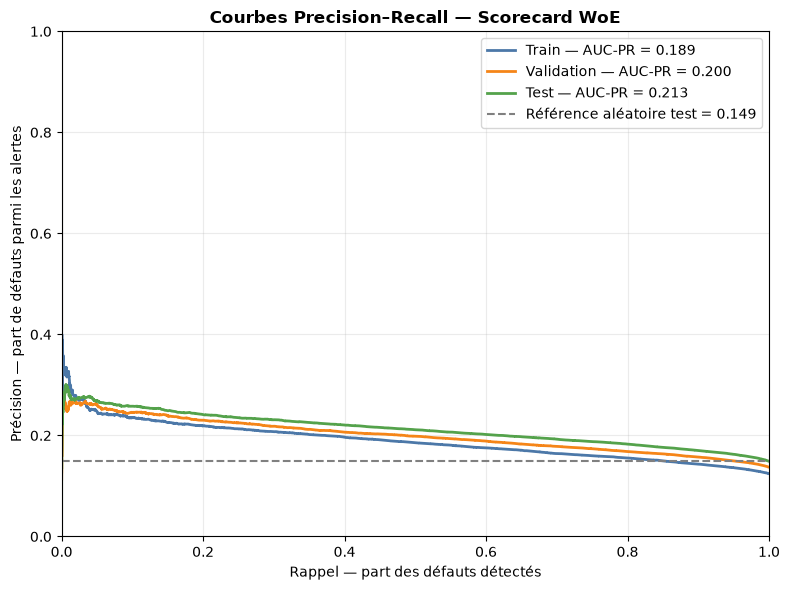

In [17]:
# ============================================================
# COURBES PRECISION-RECALL — TRAIN / VALIDATION / TEST
# ============================================================

def afficher_courbe_precision_recall(
    y_true,
    probabilites,
    nom_echantillon,
    couleur,
):
    precision, recall, _ = precision_recall_curve(
        y_true,
        probabilites,
    )

    auc_pr = average_precision_score(
        y_true,
        probabilites,
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{nom_echantillon} "
            f"— AUC-PR = {auc_pr:.3f}"
        ),
        color=couleur,
        linewidth=2,
    )

    return auc_pr


plt.figure(figsize=(8, 6))

afficher_courbe_precision_recall(
    y_train,
    proba_train,
    "Train",
    "#4C78A8",
)

afficher_courbe_precision_recall(
    y_validation,
    proba_validation,
    "Validation",
    "#F58518",
)

afficher_courbe_precision_recall(
    y_test,
    proba_test,
    "Test",
    "#54A24B",
)

plt.axhline(
    y=y_test.mean(),
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=(
        "Référence aléatoire test "
        f"= {y_test.mean():.3f}"
    ),
)

plt.title(
    "Courbes Precision–Recall — Scorecard WoE",
    fontweight="bold",
)
plt.xlabel("Rappel — part des défauts détectés")
plt.ylabel("Précision — part de défauts parmi les alertes")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The test AUC-PR of 0.213 is above the random baseline of 0.149, which means the model concentrates defaults in the accounts it ranks as the riskiest.

### Business Reading
    At low recall, precision is roughly between 25% and 30%: among the highest-risk accounts flagged by the model, about one quarter to one third actually default.
    As recall increases, precision gradually falls toward the overall default rate, which is expected: detecting more defaults requires including more lower-risk accounts.
    At recall close to 1, precision converges to about 15%, because almost all accounts are then flagged as alerts.

### Stability
The validation and test curves remain slightly above the training curve over a large part of the recall range. This does not suggest overfitting; it is possible that the validation and test periods have a slightly more favourable default rate or risk structure for separation.

The AUC-PR is consistent with the test ROC AUC of 0.630: the model provides real but moderate ranking power. It is most useful for prioritising high-risk accounts or triggering targeted manual review, rather than for predicting every default with high precision.


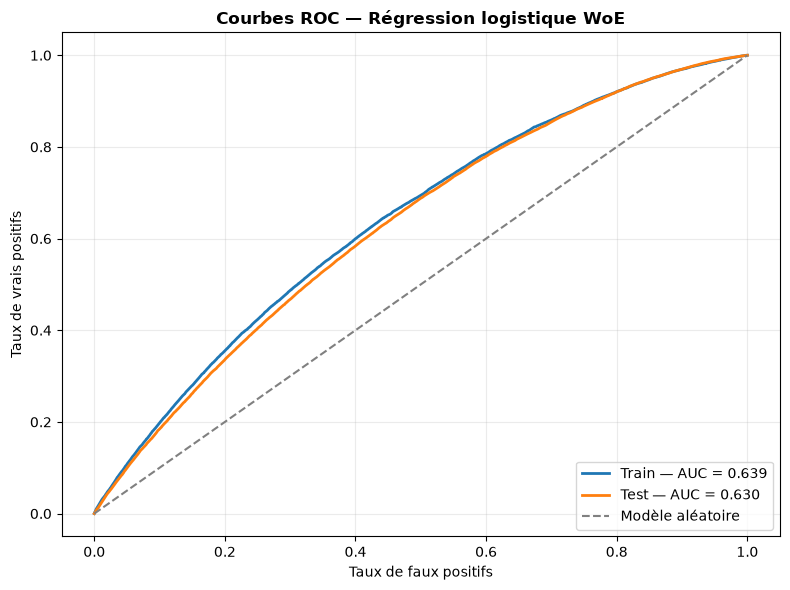

In [18]:
#Courbes ROC
fpr_train, tpr_train, _ = roc_curve(y_train, proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Train — AUC = {auc_train:.3f}",
    linewidth=2
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Test — AUC = {auc_test:.3f}",
    linewidth=2
)

plt.plot([0, 1], [0, 1], "--", color="gray", label="Modèle aléatoire")

plt.title("Courbes ROC — Régression logistique WoE", fontweight="bold")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The ROC curve shows that the model discriminates defaults better than chance and that performance is very stable between training and test. The proximity of the curves rules out marked overfitting.

### Performance
- Training AUC = 0.639: the model correctly ranks a default above a non-default in 63.9% of randomly drawn pairs.
- Test AUC = 0.630: the drop is only 0.009 points, confirming good generalisation on data not used for training.
- Both curves remain above the grey diagonal, the reference line for a random model with AUC = 0.50.

### Operational Reading
The curve is clearly above chance, especially at low false-positive rates, but it still remains relatively close to the diagonal. This corresponds to moderate discrimination, consistent with the test Gini coefficient of 0.260.

### Watch Point
An AUC of 0.630 is useful for ranking customers by risk, creating score bands, and prioritising manual review. It is not sufficient on its own to serve as a strict automated accept/reject rule: it should be combined with business criteria, compliance checks, and calibration metrics.


In [19]:
# ============================================================
# 10. INTERPRÉTATION DES COEFFICIENTS DU MODÈLE LOGISTIQUE WOE
# ============================================================

coefficients_modele = pd.DataFrame({
    "feature_woe": features_selectionnees_woe,
    "coefficient": modele_logit_woe.coef_[0],
})

coefficients_modele["feature"] = (
    coefficients_modele["feature_woe"]
    .str.replace("_woe", "", regex=False)
)

coefficients_modele["odds_ratio"] = np.exp(
    coefficients_modele["coefficient"]
)

coefficients_modele["sens_attendu"] = np.where(
    coefficients_modele["coefficient"] < 0,
    "WoE élevé -> risque de défaut plus faible",
    "WoE élevé -> risque de défaut plus élevé"
)

coefficients_modele = (
    coefficients_modele
    .sort_values("coefficient", key=np.abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Intercept du modèle : {modele_logit_woe.intercept_[0]:.4f}")

display(coefficients_modele.round({
    "coefficient": 4,
    "odds_ratio": 4,
}))


Intercept du modèle : -1.9535


,feature_woe,coefficient,feature,odds_ratio,sens_attendu
0,purpose_woe,-1.0710,purpose,0.3427,WoE élevé -> risque de défaut plus faible
1,fico_score_woe,-0.8509,fico_score,0.4270,WoE élevé -> risque de défaut plus faible
2,annual_inc_woe,-0.7734,annual_inc,0.4615,WoE élevé -> risque de défaut plus faible
3,dti_woe,-0.6242,dti,0.5357,WoE élevé -> risque de défaut plus faible
4,home_ownership_woe,-0.3713,home_ownership,0.6899,WoE élevé -> risque de défaut plus faible
5,revol_util_woe,-0.2251,revol_util,0.7985,WoE élevé -> risque de défaut plus faible


In [20]:
# ============================================================
# 11. KS STATISTIC — TRAIN / VALIDATION / TEST
# ============================================================

def calculer_ks(y_true, probabilites):
    resultat_ks = pd.DataFrame({
        "target": y_true.reset_index(drop=True),
        "proba_defaut": probabilites,
    }).sort_values("proba_defaut", ascending=False)

    resultat_ks["part_defauts_cumulee"] = (
        resultat_ks["target"].cumsum()
        / resultat_ks["target"].sum()
    )

    resultat_ks["part_non_defauts_cumulee"] = (
        (1 - resultat_ks["target"]).cumsum()
        / (1 - resultat_ks["target"]).sum()
    )

    resultat_ks["ks"] = (
        resultat_ks["part_defauts_cumulee"]
        - resultat_ks["part_non_defauts_cumulee"]
    )

    ks_max = resultat_ks["ks"].max()
    seuil_ks = resultat_ks.loc[
        resultat_ks["ks"].idxmax(),
        "proba_defaut",
    ]

    return ks_max, seuil_ks, resultat_ks


ks_train, seuil_ks_train, table_ks_train = calculer_ks(
    y_train,
    proba_train,
)

ks_validation, seuil_ks_validation, table_ks_validation = calculer_ks(
    y_validation,
    proba_validation,
)

ks_test, seuil_ks_test, table_ks_test = calculer_ks(
    y_test,
    proba_test,
)

performance_ks = pd.DataFrame({
    "échantillon": ["Train", "Validation", "Test"],
    "KS": [ks_train, ks_validation, ks_test],
    "seuil_proba_au_KS_max": [
        seuil_ks_train,
        seuil_ks_validation,
        seuil_ks_test,
    ],
})

display(performance_ks.round(4))


,échantillon,KS,seuil_proba_au_KS_max
0,Train,0.2026,0.1232
1,Validation,0.1903,0.1362
2,Test,0.1885,0.1220


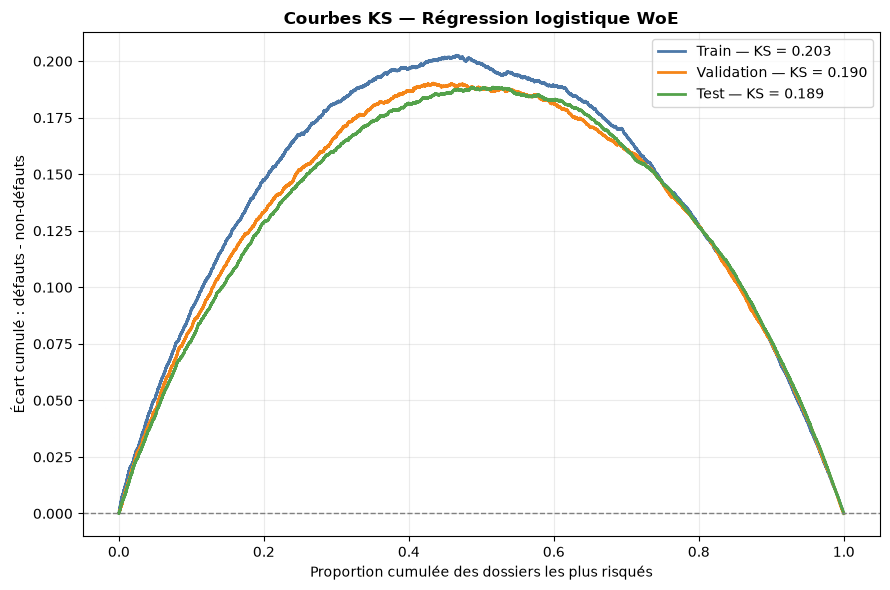

In [21]:
# ============================================================
# 12. COURBES KS — TRAIN / VALIDATION / TEST
# ============================================================

plt.figure(figsize=(9, 6))

for table_ks, nom, couleur in [
    (table_ks_train, "Train", "#4C78A8"),
    (table_ks_validation, "Validation", "#F58518"),
    (table_ks_test, "Test", "#54A24B"),
]:
    plt.plot(
        np.arange(1, len(table_ks) + 1) / len(table_ks),
        table_ks["ks"],
        label=f"{nom} — KS = {table_ks['ks'].max():.3f}",
        color=couleur,
        linewidth=2,
    )

plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Courbes KS — Régression logistique WoE",
    fontweight="bold",
)
plt.xlabel("Proportion cumulée des dossiers les plus risqués")
plt.ylabel("Écart cumulé : défauts - non-défauts")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The KS statistic measures the model’s separation power between defaulted and non-defaulted accounts. It is not directly recalibrated: default probabilities are recalibrated, whereas KS is used to assess risk ranking.

A KS of 0.189 means that at its best threshold, the model creates a maximum gap of 18.9 points between the cumulative proportion of defaults and non-defaults. In our model, the values of 0.203 on training, 0.190 on validation, and 0.189 on test are close: discrimination is stable, but only of moderate intensity.


In [22]:
# ============================================================
# 13. VALIDATION PAR DÉCILES DE RISQUE — TEST
# ============================================================

analyse_deciles_test = pd.DataFrame({
    "target": y_test.reset_index(drop=True),
    "proba_defaut": proba_test,
})

analyse_deciles_test["decile_risque"] = pd.qcut(
    analyse_deciles_test["proba_defaut"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

performance_deciles_test = (
    analyse_deciles_test
    .groupby("decile_risque", observed=False)
    .agg(
        n_dossiers=("target", "size"),
        n_defauts=("target", "sum"),
        taux_defaut=("target", "mean"),
        proba_moyenne=("proba_defaut", "mean"),
        proba_min=("proba_defaut", "min"),
        proba_max=("proba_defaut", "max"),
    )
    .reset_index()
)

performance_deciles_test = (
    performance_deciles_test
    .sort_values("decile_risque", ascending=False)
    .reset_index(drop=True)
)

performance_deciles_test["part_defauts"] = (
    performance_deciles_test["n_defauts"]
    / performance_deciles_test["n_defauts"].sum()
)

performance_deciles_test["taux_defaut_cumule"] = (
    performance_deciles_test["n_defauts"].cumsum()
    / performance_deciles_test["n_dossiers"].cumsum()
)

performance_deciles_test["lift"] = (
    performance_deciles_test["taux_defaut"]
    / analyse_deciles_test["target"].mean()
)

display(performance_deciles_test.round(4))


,decile_risque,n_dossiers,n_defauts,taux_defaut,proba_moyenne,proba_min,proba_max,part_defauts,taux_defaut_cumule,lift
0,10,28232,6937,0.2457,0.2357,0.2056,0.4257,0.1646,0.2457,1.6506
1,9,28351,6100,0.2152,0.1904,0.1772,0.2055,0.1448,0.2304,1.4454
2,8,28130,5343,0.1899,0.1664,0.1568,0.1771,0.1268,0.2170,1.2759
3,7,28465,4970,0.1746,0.1480,0.1399,0.1568,0.1180,0.2063,1.1729
4,6,28319,4443,0.1569,0.1320,0.1246,0.1398,0.1055,0.1964,1.0539
5,5,28073,4009,0.1428,0.1175,0.1104,0.1246,0.0952,0.1875,0.9593
6,4,28540,3469,0.1215,0.1035,0.0966,0.1104,0.0823,0.1780,0.8165
7,3,28305,2983,0.1054,0.0890,0.0817,0.0966,0.0708,0.1690,0.7080
8,2,28307,2410,0.0851,0.0726,0.0632,0.0817,0.0572,0.1596,0.5719
9,1,28304,1468,0.0519,0.0495,0.0266,0.0632,0.0348,0.1489,0.3484


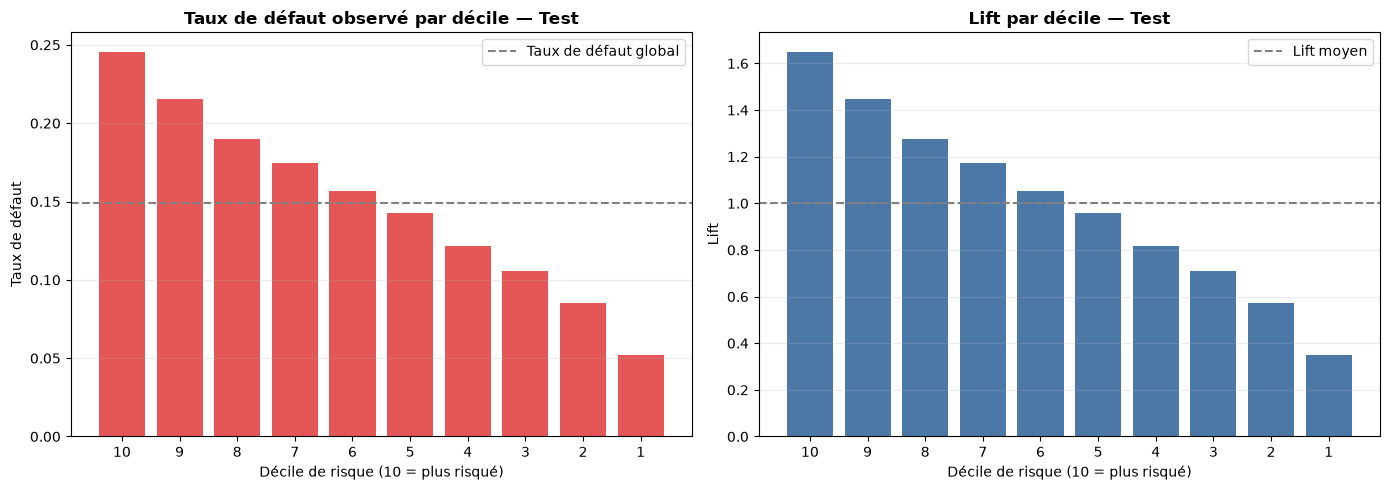

In [23]:
# ============================================================
# 14. VISUALISATION DES DÉCILES DE RISQUE — TEST
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
)

axes[0].bar(
    performance_deciles_test["decile_risque"].astype(str),
    performance_deciles_test["taux_defaut"],
    color="#E45756",
)

axes[0].axhline(
    y=analyse_deciles_test["target"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Taux de défaut global",
)

axes[0].set_title(
    "Taux de défaut observé par décile — Test",
    fontweight="bold",
)
axes[0].set_xlabel("Décile de risque (10 = plus risqué)")
axes[0].set_ylabel("Taux de défaut")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    performance_deciles_test["decile_risque"].astype(str),
    performance_deciles_test["lift"],
    color="#4C78A8",
)

axes[1].axhline(
    y=1,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Lift moyen",
)

axes[1].set_title(
    "Lift par décile — Test",
    fontweight="bold",
)
axes[1].set_xlabel("Décile de risque (10 = plus risqué)")
axes[1].set_ylabel("Lift")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


The riskiest decile shows a default rate of about 24.5%, compared with about 5.2% for the least risky decile: observed risk is therefore approximately 4.7 times higher in the riskiest segment.

### Operational Reading
- Deciles 10 to 7 are clearly above the overall default rate of about 15%; they represent the population to monitor, price more strictly, or subject to stronger acceptance rules.
- Decile 6 is close to the portfolio average, with lift near 1; it corresponds to an intermediate zone.
- Deciles 5 to 1 are below the average risk; deciles 2 and 1 are the least risky segments, with default rates below about 9%.

### Limitation
The separation is regular but still moderate, consistent with the test KS of 0.189. The model is therefore well calibrated in relative ranking, but its overall discriminative power remains limited; the deciles should be used as risk segments rather than as a single automatic acceptance rule.


,decile_risque,n_dossiers,taux_defaut_observe,proba_defaut_predite,ecart_calibration
0,1,28304,0.0519,0.0495,0.0024
1,2,28307,0.0851,0.0726,0.0125
2,3,28305,0.1054,0.0890,0.0164
3,4,28540,0.1215,0.1035,0.0180
4,5,28073,0.1428,0.1175,0.0253
5,6,28319,0.1569,0.1320,0.0249
6,7,28465,0.1746,0.1480,0.0266
7,8,28130,0.1899,0.1664,0.0236
8,9,28351,0.2152,0.1904,0.0248
9,10,28232,0.2457,0.2357,0.0100


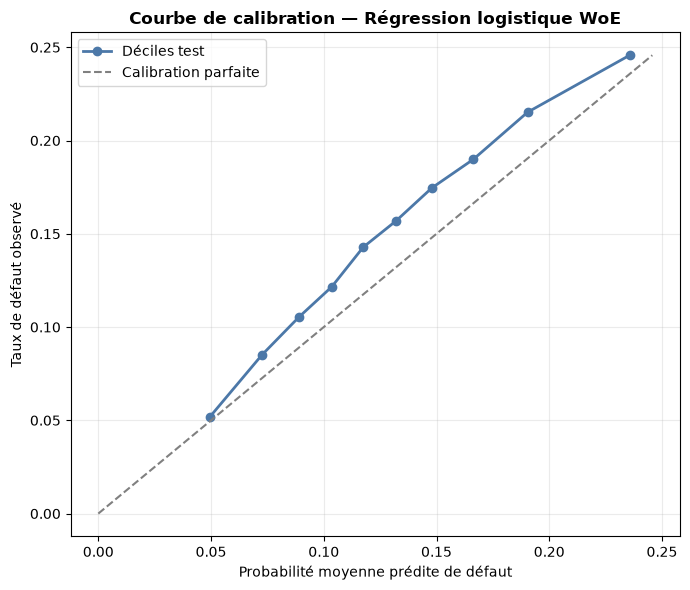

In [24]:
# ============================================================
# 15. CALIBRATION PAR DÉCILES — TEST
# ============================================================

calibration_deciles_test = (
    analyse_deciles_test
    .groupby("decile_risque", observed=False)
    .agg(
        n_dossiers=("target", "size"),
        taux_defaut_observe=("target", "mean"),
        proba_defaut_predite=("proba_defaut", "mean"),
    )
    .reset_index()
    .sort_values("decile_risque")
)

calibration_deciles_test["ecart_calibration"] = (
    calibration_deciles_test["taux_defaut_observe"]
    - calibration_deciles_test["proba_defaut_predite"]
)

display(calibration_deciles_test.round(4))

plt.figure(figsize=(7, 6))

plt.plot(
    calibration_deciles_test["proba_defaut_predite"],
    calibration_deciles_test["taux_defaut_observe"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Déciles test",
)

borne_max = max(
    calibration_deciles_test["proba_defaut_predite"].max(),
    calibration_deciles_test["taux_defaut_observe"].max(),
)

plt.plot(
    [0, borne_max],
    [0, borne_max],
    linestyle="--",
    color="gray",
    label="Calibration parfaite",
)

plt.title(
    "Courbe de calibration — Régression logistique WoE",
    fontweight="bold",
)
plt.xlabel("Probabilité moyenne prédite de défaut")
plt.ylabel("Taux de défaut observé")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [27]:
# ============================================================
# 16. RECALIBRATION SIGMOÏDE SUR LA VALIDATION
# ============================================================

# La calibration apprend le lien entre le score brut du modèle
# et la fréquence de défaut observée sur la validation.
calibrateur_sigmoide = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

calibrateur_sigmoide.fit(
    proba_validation.reshape(-1, 1),
    y_validation,
)

# Probabilités recalibrées sur le test final
proba_test_calibree = calibrateur_sigmoide.predict_proba(
    proba_test.reshape(-1, 1)
)[:, 1]

# Comparaison avant / après calibration
brier_test_avant = brier_score_loss(y_test, proba_test)
brier_test_apres = brier_score_loss(y_test, proba_test_calibree)

auc_test_calibree = roc_auc_score(y_test, proba_test_calibree)

comparaison_calibration = pd.DataFrame({
    "métrique": ["AUC test", "Brier score test"],
    "avant_calibration": [auc_test, brier_test_avant],
    "après_calibration": [auc_test_calibree, brier_test_apres],
})

comparaison_calibration["écart"] = (
    comparaison_calibration["après_calibration"]
    - comparaison_calibration["avant_calibration"]
)

display(comparaison_calibration.round(4))


,métrique,avant_calibration,après_calibration,écart
0,AUC test,0.6300,0.6300,0.0000
1,Brier score test,0.1238,0.1239,0.0001


The Brier score measures the quality of predicted probabilities: it penalises the squared difference between the predicted default probability and the observed default outcome. Unlike KS, it evaluates both calibration and, to some extent, the overall quality of probabilistic forecasts.


,decile_risque,taux_defaut_observe,proba_avant,proba_apres
0,1,0.0519,0.0495,0.0725
1,2,0.0851,0.0726,0.0856
2,3,0.1054,0.0890,0.0963
3,4,0.1215,0.1035,0.1066
4,5,0.1428,0.1175,0.1176
5,6,0.1569,0.1320,0.1300
6,7,0.1746,0.1480,0.1448
7,8,0.1899,0.1664,0.1637
8,9,0.2152,0.1904,0.1913
9,10,0.2457,0.2357,0.2540


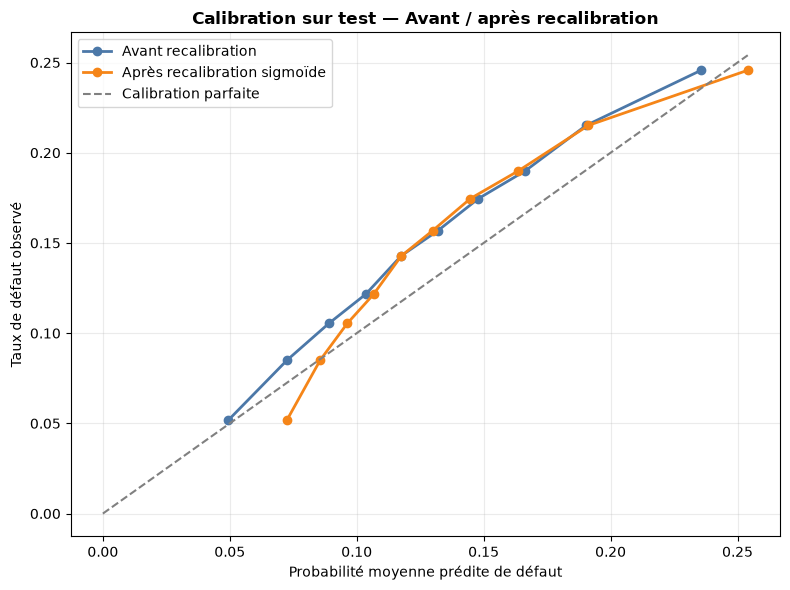

In [28]:
# ============================================================
# 17. COURBE DE CALIBRATION — AVANT / APRÈS RECALIBRATION
# ============================================================

analyse_calibration_test = pd.DataFrame({
    "target": y_test.reset_index(drop=True),
    "proba_avant": proba_test,
    "proba_apres": proba_test_calibree,
})

analyse_calibration_test["decile_risque"] = pd.qcut(
    analyse_calibration_test["proba_avant"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1

calibration_comparative_test = (
    analyse_calibration_test
    .groupby("decile_risque", observed=False)
    .agg(
        taux_defaut_observe=("target", "mean"),
        proba_avant=("proba_avant", "mean"),
        proba_apres=("proba_apres", "mean"),
    )
    .reset_index()
    .sort_values("decile_risque")
)

display(calibration_comparative_test.round(4))

borne_max = max(
    calibration_comparative_test["taux_defaut_observe"].max(),
    calibration_comparative_test["proba_avant"].max(),
    calibration_comparative_test["proba_apres"].max(),
)

plt.figure(figsize=(8, 6))

plt.plot(
    calibration_comparative_test["proba_avant"],
    calibration_comparative_test["taux_defaut_observe"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Avant recalibration",
)

plt.plot(
    calibration_comparative_test["proba_apres"],
    calibration_comparative_test["taux_defaut_observe"],
    marker="o",
    linewidth=2,
    color="#F58518",
    label="Après recalibration sigmoïde",
)

plt.plot(
    [0, borne_max],
    [0, borne_max],
    linestyle="--",
    color="gray",
    label="Calibration parfaite",
)

plt.title(
    "Calibration sur test — Avant / après recalibration",
    fontweight="bold",
)
plt.xlabel("Probabilité moyenne prédite de défaut")
plt.ylabel("Taux de défaut observé")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [29]:
# ============================================================
# 18. SYNTHÈSE FINALE — MODÈLE WOE
# ============================================================

resume_modele_final = pd.DataFrame({
    "métrique": [
        "AUC",
        "Gini",
        "KS",
        "Brier score",
    ],
    "Train": [
        auc_train,
        gini_train,
        ks_train,
        np.nan,
    ],
    "Validation": [
        auc_validation,
        gini_validation,
        ks_validation,
        np.nan,
    ],
    "Test avant calibration": [
        auc_test,
        gini_test,
        ks_test,
        brier_test_avant,
    ],
    "Test après calibration": [
        auc_test_calibree,
        2 * auc_test_calibree - 1,
        ks_test,
        brier_test_apres,
    ],
})

display(resume_modele_final.round(4))

if brier_test_apres < brier_test_avant:
    version_probabilites_retenue = "Recalibrée sigmoïde"
    proba_test_finale = proba_test_calibree
else:
    version_probabilites_retenue = "Initiale"
    proba_test_finale = proba_test

print(
    "Version retenue pour les probabilités : "
    f"{version_probabilites_retenue}"
)

print(
    f"Brier avant calibration : {brier_test_avant:.4f}"
)
print(
    f"Brier après calibration : {brier_test_apres:.4f}"
)


,métrique,Train,Validation,Test avant calibration,Test après calibration
0,AUC,0.6389,0.6318,0.6300,0.6300
1,Gini,0.2778,0.2636,0.2600,0.2600
2,KS,0.2026,0.1903,0.1885,0.1885
3,Brier score,NaN,NaN,0.1238,0.1239


Version retenue pour les probabilités : Initiale
Brier avant calibration : 0.1238
Brier après calibration : 0.1239


KS — Are defaults ranked better than non-defaults? — higher is better
AUC — What is the overall quality of ranking? — higher is better
Brier — Do the predicted probabilities match the observed events? — lower is better


In [30]:
# ============================================================
# 19. CONVERSION EN SCORECARD — POINTS DE SCORE
# ============================================================

# Convention :
# score élevé = risque faible
# odds = P(non-défaut) / P(défaut)

BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

FACTEUR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTEUR * np.log(BASE_ODDS)

intercept_modele = modele_logit_woe.intercept_[0]
coefficients_woe = pd.Series(
    modele_logit_woe.coef_[0],
    index=features_selectionnees_woe,
)

def calculer_scorecard(X_woe):
    logit_defaut = (
        intercept_modele
        + X_woe[features_selectionnees_woe]
        .mul(coefficients_woe, axis=1)
        .sum(axis=1)
    )

    score = OFFSET - FACTEUR * logit_defaut

    return score

score_train = calculer_scorecard(X_train_woe)
score_validation = calculer_scorecard(X_validation_woe)
score_test = calculer_scorecard(X_test_woe)

resume_scores = pd.DataFrame({
    "échantillon": ["Train", "Validation", "Test"],
    "score_min": [
        score_train.min(),
        score_validation.min(),
        score_test.min(),
    ],
    "score_médian": [
        score_train.median(),
        score_validation.median(),
        score_test.median(),
    ],
    "score_moyen": [
        score_train.mean(),
        score_validation.mean(),
        score_test.mean(),
    ],
    "score_max": [
        score_train.max(),
        score_validation.max(),
        score_test.max(),
    ],
})

display(resume_scores.round(1))

# Contrôle : un score élevé doit correspondre à une faible PD
controle_score_test = pd.DataFrame({
    "score": score_test,
    "proba_defaut": proba_test_finale,
})

print(
    "Corrélation score / probabilité de défaut : "
    f"{controle_score_test.corr().iloc[0, 1]:.4f}"
)


,échantillon,score_min,score_médian,score_moyen,score_max
0,Train,495.8000,545.0000,546.3000,591.0000
1,Validation,495.8000,543.0000,544.2000,591.0000
2,Test,495.8000,543.4000,544.6000,591.0000


Corrélation score / probabilité de défaut : -0.9726


The bounds are identical—roughly 496 to 591—and the means differ by only 1.7 points between training and test. This confirms that the WoE binning rules and the logistic model transfer correctly to later temporal partitions.

### Score Meaning
The correlation between score and default probability is -0.9726: as the score increases, the default probability drops very strongly. This is exactly the expected behaviour of a credit scorecard, where a higher score indicates a less risky borrower.

### Technical Note
The correlation is not exactly -1 because it is measured using Pearson correlation between a linear score and a probability obtained after a logistic transformation; the relationship is strictly decreasing but non-linear.


The next step builds the points table by bucket/category: it makes the scorecard directly interpretable by showing the contribution of each WoE interval to the final score. It reuses the WoE rules, coefficients, and score parameters already defined in your notebook.


In [31]:
# ============================================================
# 20. TABLE DE POINTS PAR BUCKET — SCORECARD
# ============================================================

points_intercept = OFFSET - FACTEUR * intercept_modele

scorecard_points = (
    woe_detail
    .loc[
        woe_detail["feature"].isin(features_selectionnees)
    ]
    .copy()
)

scorecard_points["feature_woe"] = (
    scorecard_points["feature"] + "_woe"
)

scorecard_points["coefficient"] = (
    scorecard_points["feature_woe"]
    .map(coefficients_woe)
)

scorecard_points["points_bucket"] = (
    - FACTEUR
    * scorecard_points["coefficient"]
    * scorecard_points["woe"]
)

scorecard_points["type_variable"] = np.where(
    scorecard_points["feature"].isin(NUMERIC_FEATURES),
    "Numérique",
    "Catégorielle",
)

scorecard_points = (
    scorecard_points[
        [
            "feature",
            "type_variable",
            "bucket",
            "woe",
            "coefficient",
            "points_bucket",
            "n_loans",
            "n_defaults",
            "default_rate",
            "iv_component",
        ]
    ]
    .sort_values(["feature", "points_bucket"])
    .reset_index(drop=True)
)

print(f"Points fixes de l'intercept : {points_intercept:.2f}")

display(
    scorecard_points.round({
        "woe": 4,
        "coefficient": 4,
        "points_bucket": 2,
        "default_rate": 4,
        "iv_component": 4,
    })
)


Points fixes de l'intercept : 543.49


,feature,type_variable,bucket,woe,coefficient,points_bucket,n_loans,n_defaults,default_rate,iv_component
0,annual_inc,Numérique,"(-inf, 39000.0]",-0.3882,-0.7734,-8.6600,34616,5992,0.1731,0.0348
1,annual_inc,Numérique,"(39000.0, 52000.0]",-0.1512,-0.7734,-3.3700,36633,5193,0.1418,0.0051
2,annual_inc,Numérique,"(52000.0, 67800.0]",0.0177,-0.7734,0.4000,32553,3985,0.1224,0.0001
3,annual_inc,Numérique,"(67800.0, 90000.0]",0.2229,-0.7734,4.9700,34620,3532,0.1020,0.0091
4,annual_inc,Numérique,"(90000.0, inf]",0.4744,-0.7734,10.5900,34566,2806,0.0812,0.0376
5,dti,Numérique,"(22.9, inf]",-0.2740,-0.6242,-4.9400,34582,5442,0.1574,0.0166
6,dti,Numérique,"(17.92, 22.9]",-0.1026,-0.6242,-1.8500,34544,4696,0.1359,0.0022
7,dti,Numérique,"(13.64, 17.92]",0.0186,-0.6242,0.3300,34654,4239,0.1223,0.0001
8,dti,Numérique,"(9.11, 13.64]",0.1625,-0.6242,2.9300,34561,3722,0.1077,0.0050
9,dti,Numérique,"(-inf, 9.11]",0.2632,-0.6242,4.7400,34647,3409,0.0984,0.0126


In [32]:
# ============================================================
# 21. CONTRÔLE DE RECONSTITUTION DU SCORE — TEST
# ============================================================

points_mapping = (
    scorecard_points
    .set_index(["feature", "bucket"])["points_bucket"]
    .to_dict()
)

points_variables_test = pd.DataFrame(
    index=X_test.index,
)

for feature in features_selectionnees:
    feature_woe = f"{feature}_woe"

    buckets_test = (
        make_numeric_bucket(
            series=X_test[feature],
            bin_edges=woe_rules["numeric_edges"][feature],
        )
        if feature in NUMERIC_FEATURES
        else make_categorical_bucket(
            series=X_test[feature],
            retained_categories=woe_rules[
                "categorical_retained_categories"
            ][feature],
        )
    )

    points_variables_test[feature] = [
        points_mapping.get(
            (feature, bucket),
            0.0,
        )
        for bucket in buckets_test
    ]

score_test_reconstitue = (
    points_intercept
    + points_variables_test.sum(axis=1)
)

controle_reconstitution = pd.DataFrame({
    "score_modele": score_test.to_numpy(),
    "score_reconstitue": score_test_reconstitue.to_numpy(),
})

controle_reconstitution["ecart"] = (
    controle_reconstitution["score_modele"]
    - controle_reconstitution["score_reconstitue"]
)

print(
    "Écart absolu maximal : "
    f"{controle_reconstitution['ecart'].abs().max():.10f}"
)

display(controle_reconstitution.head(10).round(4))

assert np.isclose(
    controle_reconstitution["ecart"].abs().max(),
    0,
    atol=1e-8,
), "La table de points ne reconstitue pas exactement le score."


Écart absolu maximal : 0.0000000000


,score_modele,score_reconstitue,ecart
0,547.0533,547.0533,0.0000
1,533.4523,533.4523,0.0000
2,533.9623,533.9623,0.0000
3,549.2405,549.2405,0.0000
4,568.7281,568.7281,0.0000
5,551.1629,551.1629,0.0000
6,543.2608,543.2608,0.0000
7,531.8079,531.8079,0.0000
8,559.1874,559.1874,0.0000
9,549.6230,549.6230,0.0000


In [33]:
# ============================================================
# 22. EXPORT DES ARTEFACTS — SCORECARD LOGISTIQUE WOE V1
# ============================================================

parametres_scorecard = pd.DataFrame({
    "parametre": [
        "base_score",
        "base_odds_non_defaut_sur_defaut",
        "pdo",
        "facteur",
        "offset",
        "points_intercept",
        "version_probabilites_retenue",
    ],
    "valeur": [
        BASE_SCORE,
        BASE_ODDS,
        PDO,
        FACTEUR,
        OFFSET,
        points_intercept,
        version_probabilites_retenue,
    ],
})

scorecard_points.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_points_par_bucket.csv",
    index=False,
)

resume_modele_final.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_performance.csv",
    index=False,
)

performance_deciles_test.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_deciles_test.csv",
    index=False,
)

parametres_scorecard.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_parametres.csv",
    index=False,
)

coefficients_modele.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_coefficients.csv",
    index=False,
)

print("Artefacts exportés :")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_points_par_bucket.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_performance.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_deciles_test.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_parametres.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_coefficients.csv")


Artefacts exportés :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_points_par_bucket.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_performance.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_deciles_test.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_parametres.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_coefficients.csv


In [34]:
# ============================================================
# 23. BANDES DE SCORE — SEUILS SUR VALIDATION, TEST FINAL
# ============================================================

# 1 = risque le plus élevé ; 5 = risque le plus faible
seuils_score = np.unique(
    np.quantile(
        score_validation,
        q=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
    )
)

labels_bandes = [
    "1 - Très risqué",
    "2 - Risqué",
    "3 - Intermédiaire",
    "4 - Faible risque",
    "5 - Très faible risque",
]

assert len(seuils_score) == len(labels_bandes) + 1, (
    "Les seuils ne permettent pas de créer cinq bandes distinctes."
)

analyse_bandes_test = pd.DataFrame({
    "score": score_test.to_numpy(),
    "proba_defaut": proba_test_finale,
    "target": y_test.to_numpy(),
})

analyse_bandes_test["bande_score"] = pd.cut(
    analyse_bandes_test["score"],
    bins=seuils_score,
    labels=labels_bandes,
    include_lowest=True,
)

performance_bandes_test = (
    analyse_bandes_test
    .groupby("bande_score", observed=False)
    .agg(
        score_min=("score", "min"),
        score_max=("score", "max"),
        n_dossiers=("target", "size"),
        n_defauts=("target", "sum"),
        taux_defaut_observe=("target", "mean"),
        pd_moyenne_predite=("proba_defaut", "mean"),
    )
    .reset_index()
)

performance_bandes_test["part_portefeuille"] = (
    performance_bandes_test["n_dossiers"]
    / performance_bandes_test["n_dossiers"].sum()
)

performance_bandes_test["lift"] = (
    performance_bandes_test["taux_defaut_observe"]
    / y_test.mean()
)

display(
    performance_bandes_test.round({
        "score_min": 1,
        "score_max": 1,
        "taux_defaut_observe": 4,
        "pd_moyenne_predite": 4,
        "part_portefeuille": 4,
        "lift": 2,
    })
)


,bande_score,score_min,score_max,n_dossiers,n_defauts,taux_defaut_observe,pd_moyenne_predite,part_portefeuille,lift
0,1 - Très risqué,495.8000,531.2000,54590,12607,0.2309,0.2143,0.1929,1.5500
1,2 - Risqué,531.2000,539.1000,55858,10270,0.1839,0.1586,0.1974,1.2400
2,3 - Intermédiaire,539.1000,546.9000,56613,8558,0.1512,0.1262,0.2000,1.0200
3,4 - Faible risque,546.9000,556.6000,57722,6671,0.1156,0.0973,0.2039,0.7800
4,5 - Très faible risque,556.6000,591.0000,58243,4026,0.0691,0.0617,0.2058,0.4600


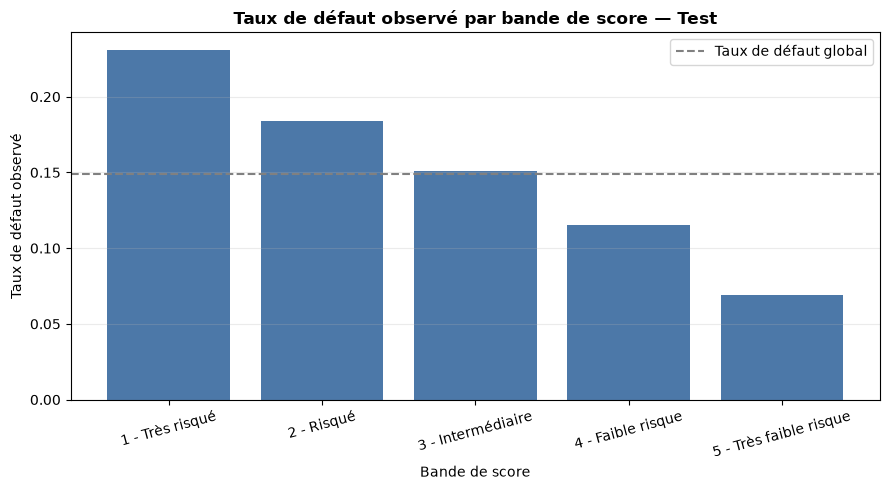

,bande_score,score_min,score_max,n_dossiers,taux_defaut_observe,pd_moyenne_predite,lift
0,1 - Très risqué,495.8000,531.2000,54590,0.2309,0.2143,1.5500
1,2 - Risqué,531.2000,539.1000,55858,0.1839,0.1586,1.2400
2,3 - Intermédiaire,539.1000,546.9000,56613,0.1512,0.1262,1.0200
3,4 - Faible risque,546.9000,556.6000,57722,0.1156,0.0973,0.7800
4,5 - Très faible risque,556.6000,591.0000,58243,0.0691,0.0617,0.4600


In [35]:
# ============================================================
# 24. VISUALISATION DES BANDES DE SCORE — TEST
# ============================================================

performance_bandes_plot = (
    performance_bandes_test
    .copy()
    .sort_values("score_min")
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))

plt.bar(
    performance_bandes_plot["bande_score"],
    performance_bandes_plot["taux_defaut_observe"],
    color="#4C78A8",
)

plt.axhline(
    y=y_test.mean(),
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Taux de défaut global",
)

plt.title(
    "Taux de défaut observé par bande de score — Test",
    fontweight="bold",
)
plt.xlabel("Bande de score")
plt.ylabel("Taux de défaut observé")
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    performance_bandes_plot[
        [
            "bande_score",
            "score_min",
            "score_max",
            "n_dossiers",
            "taux_defaut_observe",
            "pd_moyenne_predite",
            "lift",
        ]
    ].round({
        "score_min": 1,
        "score_max": 1,
        "taux_defaut_observe": 4,
        "pd_moyenne_predite": 4,
        "lift": 2,
    })
)


The score bands are highly coherent: the default rate decreases strictly and steadily from the “Very risky” segment to the “Very low risk” segment. This confirms that the scorecard correctly translates the numerical score into operational risk categories.

Band 1 has a default rate about 3.3 times higher than Band 5, providing a clear differentiation for portfolio segmentation.

### Business Use
    - Bands 1–2: prioritise manual review, apply stronger acceptance criteria, or charge a higher price, subject to business and compliance rules.
    - Band 3: intermediate population; handle with standard policies.
    - Bands 4–5: relatively less risky profiles; they may justify a simplified journey or more favourable terms, depending on the commercial strategy.

### Limitation
The separation is monotonic and actionable, but still moderate in absolute level, which is consistent with your test KS of about 0.189. The bands are therefore useful as a decision-support and segmentation tool, rather than as the sole automatic acceptance rule.


The next step measures the Population Stability Index (PSI) of the scores between training, validation, and test. This checks whether the distribution of risk profiles has drifted materially over time.


In [36]:
# ============================================================
# 25. PSI DES SCORES — TRAIN / VALIDATION / TEST
# ============================================================

# Bornes de référence apprises sur le train uniquement
bornes_psi = np.quantile(
    score_train,
    q=np.linspace(0, 1, 11),
)

bornes_psi[0] = -np.inf
bornes_psi[-1] = np.inf

assert len(np.unique(bornes_psi)) == len(bornes_psi), (
    "Des bornes PSI sont dupliquées : vérifier la variabilité des scores."
)

def calculer_psi(score_reference, score_compare, bornes):
    repartition_reference = pd.cut(
        score_reference,
        bins=bornes,
        include_lowest=True,
    ).value_counts(normalize=True, sort=False)

    repartition_comparee = pd.cut(
        score_compare,
        bins=bornes,
        include_lowest=True,
    ).value_counts(normalize=True, sort=False)

    table_psi = pd.DataFrame({
        "bande_score": repartition_reference.index.astype(str),
        "part_reference": repartition_reference.to_numpy(),
        "part_comparee": repartition_comparee.to_numpy(),
    })

    # Évite les logarithmes de zéro
    table_psi["part_reference"] = (
        table_psi["part_reference"].clip(lower=0.0001)
    )
    table_psi["part_comparee"] = (
        table_psi["part_comparee"].clip(lower=0.0001)
    )

    table_psi["contribution_psi"] = (
        (table_psi["part_comparee"] - table_psi["part_reference"])
        * np.log(
            table_psi["part_comparee"]
            / table_psi["part_reference"]
        )
    )

    return table_psi, table_psi["contribution_psi"].sum()


table_psi_validation, psi_validation = calculer_psi(
    score_reference=score_train,
    score_compare=score_validation,
    bornes=bornes_psi,
)

table_psi_test, psi_test = calculer_psi(
    score_reference=score_train,
    score_compare=score_test,
    bornes=bornes_psi,
)

resume_psi_scores = pd.DataFrame({
    "comparaison": [
        "Train vs Validation",
        "Train vs Test",
    ],
    "PSI_score": [
        psi_validation,
        psi_test,
    ],
})

resume_psi_scores["interprétation"] = np.select(
    [
        resume_psi_scores["PSI_score"] < 0.10,
        resume_psi_scores["PSI_score"] < 0.25,
    ],
    [
        "Stable",
        "Dérive modérée à surveiller",
    ],
    default="Dérive forte à investiguer",
)

display(resume_psi_scores.round(4))


,comparaison,PSI_score,interprétation
0,Train vs Validation,0.0188,Stable
1,Train vs Test,0.0131,Stable


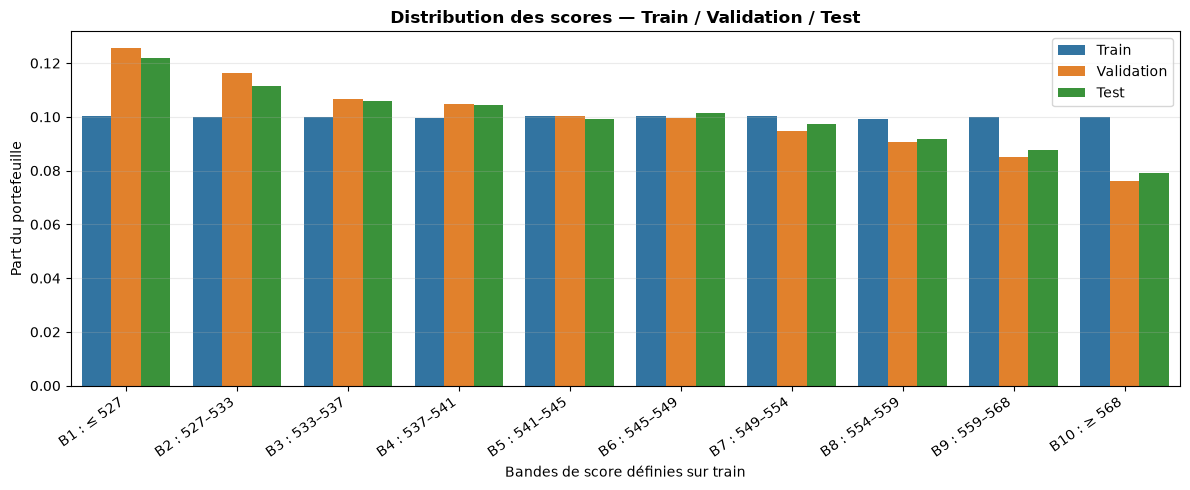

,bande_score,Train,Validation,Test
0,B1 : ≤ 527,0.1002,0.1255,0.1219
1,B2 : 527–533,0.1000,0.1164,0.1114
2,B3 : 533–537,0.1000,0.1067,0.1058
3,B4 : 537–541,0.0998,0.1048,0.1043
4,B5 : 541–545,0.1002,0.1002,0.0991
5,B6 : 545–549,0.1002,0.0997,0.1013
6,B7 : 549–554,0.1003,0.0948,0.0972
7,B8 : 554–559,0.0993,0.0907,0.0919
8,B9 : 559–568,0.1000,0.0849,0.0878
9,B10 : ≥ 568,0.1000,0.0763,0.0792


In [38]:
# ============================================================
# 26. VISUALISATION DE LA STABILITÉ DES SCORES
# ============================================================

distribution_psi = pd.DataFrame({
    "bande_score": table_psi_test["bande_score"],
    "Train": table_psi_test["part_reference"],
    "Validation": table_psi_validation["part_comparee"],
    "Test": table_psi_test["part_comparee"],
})

distribution_psi["bande_score"] = [
    f"B1 : ≤ {bornes_psi[1]:.0f}",
    f"B2 : {bornes_psi[1]:.0f}–{bornes_psi[2]:.0f}",
    f"B3 : {bornes_psi[2]:.0f}–{bornes_psi[3]:.0f}",
    f"B4 : {bornes_psi[3]:.0f}–{bornes_psi[4]:.0f}",
    f"B5 : {bornes_psi[4]:.0f}–{bornes_psi[5]:.0f}",
    f"B6 : {bornes_psi[5]:.0f}–{bornes_psi[6]:.0f}",
    f"B7 : {bornes_psi[6]:.0f}–{bornes_psi[7]:.0f}",
    f"B8 : {bornes_psi[7]:.0f}–{bornes_psi[8]:.0f}",
    f"B9 : {bornes_psi[8]:.0f}–{bornes_psi[9]:.0f}",
    f"B10 : ≥ {bornes_psi[9]:.0f}",
]


distribution_psi_long = distribution_psi.melt(
    id_vars="bande_score",
    var_name="échantillon",
    value_name="part_portefeuille",
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=distribution_psi_long,
    x="bande_score",
    y="part_portefeuille",
    hue="échantillon",
)

plt.title(
    "Distribution des scores — Train / Validation / Test",
    fontweight="bold",
)
plt.xlabel("Bandes de score définies sur train")
plt.ylabel("Part du portefeuille")
plt.xticks(rotation=35, ha="right")
plt.legend(title="")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    distribution_psi.round({
        "Train": 4,
        "Validation": 4,
        "Test": 4,
    })
)


The score distribution is globally stable, but validation and test are slightly shifted toward the lower scores—and therefore toward somewhat riskier profiles—relative to training.

### Reading the Chart
    - Training is 10% in each band because the PSI cut-offs were created from its deciles.
    - In validation and test, the first score band captures about 12–12.5% of the portfolio, compared with 10% in training; the highest bands capture fewer accounts, around 7.5–9%.
    - The middle bands stay very close to 10% across the three samples, indicating that drift is limited and concentrated mainly at the tails of the distribution.

### Interpretation
This suggests a slight temporal shift toward more low-score accounts, or fewer high-score accounts. This is consistent with your KS performance, which remains close across training (0.203), validation (0.190), and test (0.189): the population moved a little, but the model’s ranking power remained stable.

The final conclusion nevertheless depends on the calculated values of `psi_validation` and `psi_test`:
- PSI < 0.10: low drift, stable model.
- 0.10 to 0.25: moderate drift, monitor closely.
- PSI > 0.25: significant drift, investigate before deployment.


The next step computes PSI for each retained feature between training and test. It helps identify which feature explains any drift observed in the overall score distribution.


In [39]:
# ============================================================
# 27. PSI PAR VARIABLE — TRAIN VS TEST
# ============================================================

def calculer_psi_variable(feature, train_data, test_data):
    if feature in NUMERIC_FEATURES:
        buckets_train = make_numeric_bucket(
            series=train_data[feature],
            bin_edges=woe_rules["numeric_edges"][feature],
        )
        buckets_test = make_numeric_bucket(
            series=test_data[feature],
            bin_edges=woe_rules["numeric_edges"][feature],
        )
    else:
        buckets_train = make_categorical_bucket(
            series=train_data[feature],
            retained_categories=woe_rules[
                "categorical_retained_categories"
            ][feature],
        )
        buckets_test = make_categorical_bucket(
            series=test_data[feature],
            retained_categories=woe_rules[
                "categorical_retained_categories"
            ][feature],
        )

    parts_train = buckets_train.value_counts(
        normalize=True,
        dropna=False,
    )

    parts_test = buckets_test.value_counts(
        normalize=True,
        dropna=False,
    )

    modalites = parts_train.index.union(parts_test.index)

    table_psi_feature = pd.DataFrame({
        "bucket": modalites.astype(str),
        "part_train": parts_train.reindex(
            modalites,
            fill_value=0.0,
        ).to_numpy(),
        "part_test": parts_test.reindex(
            modalites,
            fill_value=0.0,
        ).to_numpy(),
    })

    table_psi_feature["part_train"] = (
        table_psi_feature["part_train"].clip(lower=0.0001)
    )

    table_psi_feature["part_test"] = (
        table_psi_feature["part_test"].clip(lower=0.0001)
    )

    table_psi_feature["contribution_psi"] = (
        (table_psi_feature["part_test"] - table_psi_feature["part_train"])
        * np.log(
            table_psi_feature["part_test"]
            / table_psi_feature["part_train"]
        )
    )

    table_psi_feature["feature"] = feature

    return table_psi_feature


tables_psi_variables = []

for feature in features_selectionnees:
    tables_psi_variables.append(
        calculer_psi_variable(
            feature=feature,
            train_data=X_train,
            test_data=X_test,
        )
    )

psi_variables_detail = pd.concat(
    tables_psi_variables,
    ignore_index=True,
)

resume_psi_variables = (
    psi_variables_detail
    .groupby("feature", as_index=False)
    .agg(
        PSI=("contribution_psi", "sum"),
    )
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

resume_psi_variables["interprétation"] = np.select(
    [
        resume_psi_variables["PSI"] < 0.10,
        resume_psi_variables["PSI"] < 0.25,
    ],
    [
        "Stable",
        "Dérive modérée à surveiller",
    ],
    default="Dérive forte à investiguer",
)

display(resume_psi_variables.round(4))


,feature,PSI,interprétation
0,purpose,0.0698,Stable
1,dti,0.0659,Stable
2,fico_score,0.0531,Stable
3,revol_util,0.0316,Stable
4,home_ownership,0.0110,Stable
5,annual_inc,0.0086,Stable


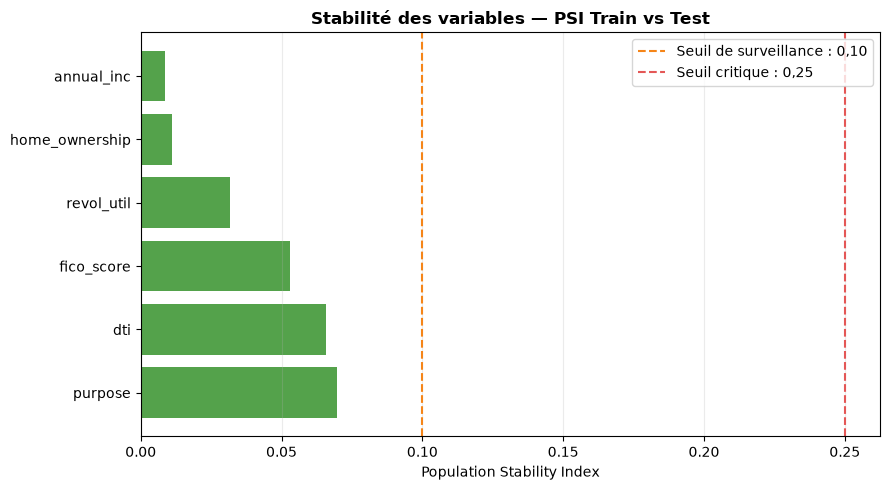

,feature,PSI,interprétation
0,purpose,0.0698,Stable
1,dti,0.0659,Stable
2,fico_score,0.0531,Stable
3,revol_util,0.0316,Stable
4,home_ownership,0.0110,Stable
5,annual_inc,0.0086,Stable


In [40]:
# ============================================================
# 28. VISUALISATION DU PSI PAR VARIABLE — TRAIN VS TEST
# ============================================================

psi_variables_plot = (
    resume_psi_variables
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

couleurs_psi = np.select(
    [
        psi_variables_plot["PSI"] < 0.10,
        psi_variables_plot["PSI"] < 0.25,
    ],
    [
        "#54A24B",
        "#F58518",
    ],
    default="#E45756",
)

plt.figure(figsize=(9, 5))

plt.barh(
    psi_variables_plot["feature"],
    psi_variables_plot["PSI"],
    color=couleurs_psi,
)

plt.axvline(
    x=0.10,
    color="#F58518",
    linestyle="--",
    linewidth=1.5,
    label="Seuil de surveillance : 0,10",
)

plt.axvline(
    x=0.25,
    color="#E45756",
    linestyle="--",
    linewidth=1.5,
    label="Seuil critique : 0,25",
)

plt.title(
    "Stabilité des variables — PSI Train vs Test",
    fontweight="bold",
)
plt.xlabel("Population Stability Index")
plt.ylabel("")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(psi_variables_plot.round(4))


Variable analysée : purpose
PSI global : 0.0698


,bucket,part_train,part_test,contribution_psi,feature,écart_part
0,wedding,0.0109,0.0001,0.0509,purpose,-0.0108
1,small_business,0.0193,0.0086,0.0088,purpose,-0.0108
2,major_purchase,0.0271,0.0189,0.0030,purpose,-0.0083
3,car,0.0151,0.0098,0.0023,purpose,-0.0054
4,credit_card,0.2274,0.2496,0.0021,purpose,0.0222
5,Other,0.0240,0.0188,0.0013,purpose,-0.0052
6,debt_consolidation,0.5492,0.5688,0.0007,purpose,0.0196
7,other,0.0591,0.0538,0.0005,purpose,-0.0053
8,home_improvement,0.0568,0.0606,0.0002,purpose,0.0038
9,medical,0.0109,0.0111,0.0000,purpose,0.0003


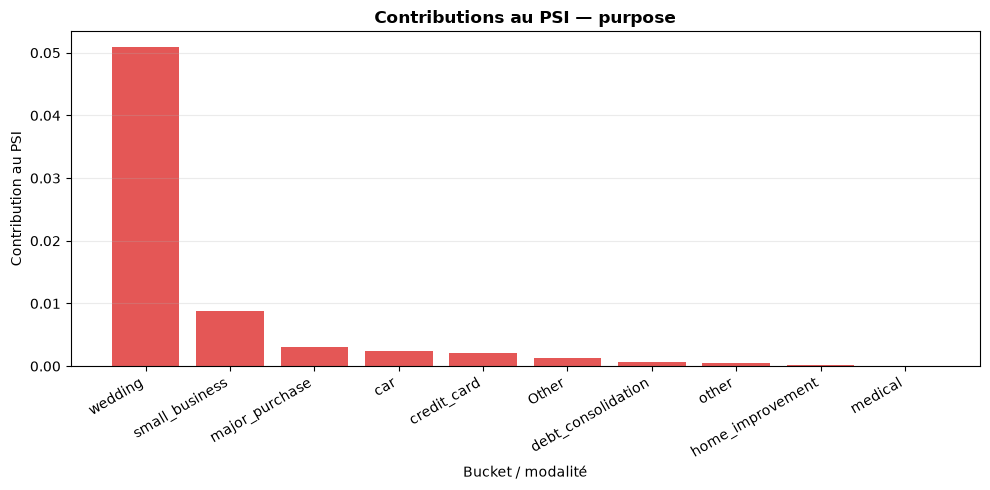

In [41]:
# ============================================================
# 29. DIAGNOSTIC DE LA VARIABLE AU PSI LE PLUS ÉLEVÉ
# ============================================================

feature_a_auditer = psi_variables_plot.loc[0, "feature"]

diagnostic_psi_feature = (
    psi_variables_detail
    .loc[
        psi_variables_detail["feature"] == feature_a_auditer
    ]
    .copy()
    .sort_values("contribution_psi", ascending=False)
    .reset_index(drop=True)
)

diagnostic_psi_feature["écart_part"] = (
    diagnostic_psi_feature["part_test"]
    - diagnostic_psi_feature["part_train"]
)

print(
    "Variable analysée : "
    f"{feature_a_auditer}"
)

print(
    "PSI global : "
    f"{psi_variables_plot.loc[0, 'PSI']:.4f}"
)

display(
    diagnostic_psi_feature.round({
        "part_train": 4,
        "part_test": 4,
        "écart_part": 4,
        "contribution_psi": 4,
    })
)

plt.figure(figsize=(10, 5))

plt.bar(
    diagnostic_psi_feature["bucket"],
    diagnostic_psi_feature["contribution_psi"],
    color="#E45756",
)

plt.title(
    f"Contributions au PSI — {feature_a_auditer}",
    fontweight="bold",
)
plt.xlabel("Bucket / modalité")
plt.ylabel("Contribution au PSI")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


The drift in `purpose` is driven almost entirely by the `wedding` category, whose contribution to PSI is about 0.051. `small_business` is a distant second at around 0.009; the other purposes contribute very little to the drift.

### Reading
    - Portfolio composition therefore changed mainly on wedding-related loans: their proportion is materially different between training and test.
    - The `purpose` PSI may remain below the global monitoring threshold of 0.10, but an isolated contribution of 0.051 deserves specific monitoring, especially because `purpose` is also a retained scorecard feature.
    - The presence of `Other` and `other` is normal in your processing: `Other` likely corresponds to grouped rare or unseen categories, whereas `other` is a distinct original category.



In [42]:
# ============================================================
# 30. STABILITÉ DU RISQUE PAR MODALITÉ — PURPOSE
# ============================================================

feature_stabilite = feature_a_auditer

def creer_table_stabilite_feature(
    X_split,
    y_split,
    nom_split,
    feature,
):
    buckets = make_categorical_bucket(
        series=X_split[feature],
        retained_categories=woe_rules[
            "categorical_retained_categories"
        ][feature],
    )

    table = pd.DataFrame({
        "bucket": buckets.to_numpy(),
        "target": y_split.to_numpy(),
    })

    table = (
        table
        .groupby("bucket", observed=False)
        .agg(
            n_dossiers=("target", "size"),
            n_defauts=("target", "sum"),
            taux_defaut=("target", "mean"),
        )
        .reset_index()
    )

    table["part_portefeuille"] = (
        table["n_dossiers"]
        / table["n_dossiers"].sum()
    )

    table["échantillon"] = nom_split

    return table


stabilite_purpose = pd.concat(
    [
        creer_table_stabilite_feature(
            X_train,
            y_train,
            "Train",
            feature_stabilite,
        ),
        creer_table_stabilite_feature(
            X_validation,
            y_validation,
            "Validation",
            feature_stabilite,
        ),
        creer_table_stabilite_feature(
            X_test,
            y_test,
            "Test",
            feature_stabilite,
        ),
    ],
    ignore_index=True,
)

stabilite_purpose_pivot = (
    stabilite_purpose
    .pivot(
        index="bucket",
        columns="échantillon",
        values=[
            "part_portefeuille",
            "taux_defaut",
            "n_dossiers",
        ],
    )
)

stabilite_purpose_pivot.columns = [
    f"{mesure}_{echantillon}"
    for mesure, echantillon in stabilite_purpose_pivot.columns
]

stabilite_purpose_pivot = (
    stabilite_purpose_pivot
    .reset_index()
    .sort_values(
        "part_portefeuille_Test",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(stabilite_purpose_pivot.round(4))


,bucket,part_portefeuille_Test,part_portefeuille_Train,part_portefeuille_Validation,taux_defaut_Test,taux_defaut_Train,taux_defaut_Validation,n_dossiers_Test,n_dossiers_Train,n_dossiers_Validation
0,debt_consolidation,0.5688,0.5492,0.5833,0.1573,0.1282,0.1436,"160,983.0000","95,006.0000","94,822.0000"
1,credit_card,0.2496,0.2274,0.2467,0.1223,0.1053,0.1156,"70,650.0000","39,335.0000","40,100.0000"
2,home_improvement,0.0606,0.0568,0.0532,0.1351,0.1082,0.1189,"17,160.0000","9,833.0000","8,654.0000"
3,other,0.0538,0.0591,0.0508,0.1686,0.1564,0.1528,"15,227.0000","10,229.0000","8,252.0000"
4,major_purchase,0.0189,0.0271,0.0178,0.1445,0.0939,0.1350,"5,342.0000","4,694.0000","2,888.0000"
5,Other,0.0188,0.0240,0.0173,0.1915,0.1458,0.1853,"5,322.0000","4,157.0000","2,811.0000"
6,medical,0.0111,0.0109,0.0116,0.1783,0.1543,0.1703,"3,146.0000","1,879.0000","1,885.0000"
7,car,0.0098,0.0151,0.0093,0.1329,0.0936,0.1154,"2,768.0000","2,618.0000","1,516.0000"
8,small_business,0.0086,0.0193,0.0101,0.2297,0.2188,0.2252,"2,425.0000","3,345.0000","1,634.0000"
9,wedding,0.0000,0.0109,0.0000,0.0000,0.1105,0.0000,3.0000,"1,892.0000",8.0000


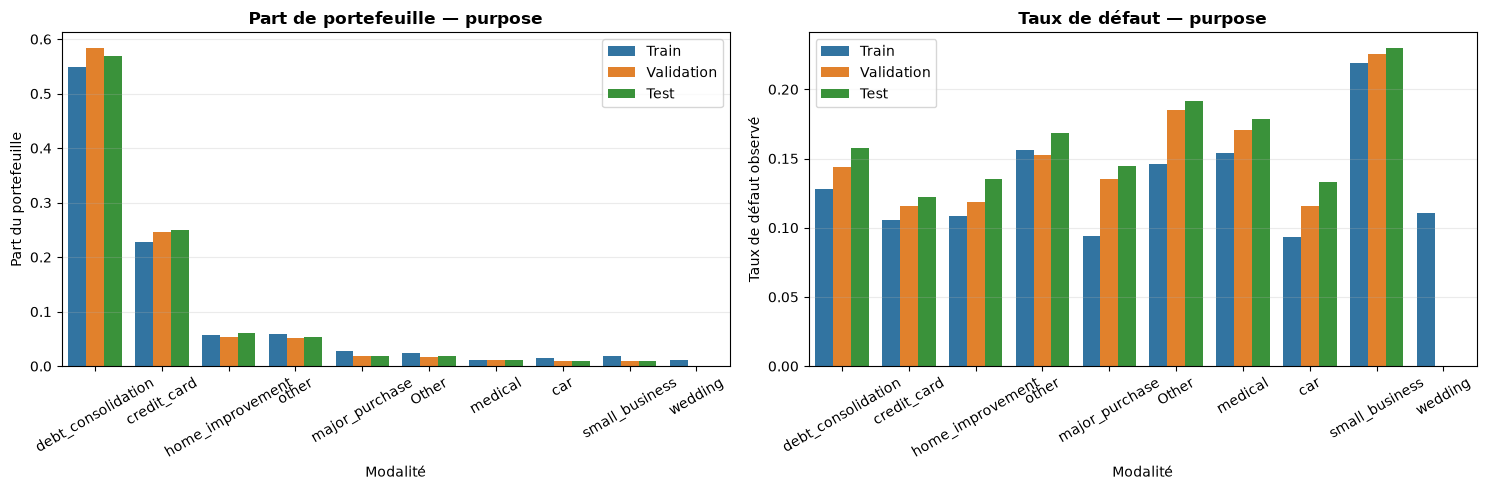

In [43]:
# ============================================================
# 31. VISUALISATION DE LA STABILITÉ — PURPOSE
# ============================================================

ordre_modalites = (
    stabilite_purpose
    .loc[
        stabilite_purpose["échantillon"] == "Test"
    ]
    .sort_values("part_portefeuille", ascending=False)["bucket"]
    .tolist()
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5),
)

sns.barplot(
    data=stabilite_purpose,
    x="bucket",
    y="part_portefeuille",
    hue="échantillon",
    order=ordre_modalites,
    ax=axes[0],
)

axes[0].set_title(
    f"Part de portefeuille — {feature_stabilite}",
    fontweight="bold",
)
axes[0].set_xlabel("Modalité")
axes[0].set_ylabel("Part du portefeuille")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.25)

sns.barplot(
    data=stabilite_purpose,
    x="bucket",
    y="taux_defaut",
    hue="échantillon",
    order=ordre_modalites,
    ax=axes[1],
)

axes[1].set_title(
    f"Taux de défaut — {feature_stabilite}",
    fontweight="bold",
)
axes[1].set_xlabel("Modalité")
axes[1].set_ylabel("Taux de défaut observé")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.25)

# Évite les légendes dupliquées
axes[0].legend(title="")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


The drift in `purpose` is mostly due to the disappearance of the `wedding` category after the training period, even though it was present in the development portfolio. It is this category break—rather than a broad change in all purposes—that explains its strong PSI contribution.

### Portfolio Composition
The dominant purposes remain fairly stable:
    - `debt_consolidation` accounts for about 55% of training, 58% of validation, and 57% of test.
    - `credit_card` increases slightly, from about 23% to 25%.
    - The other major categories vary little in proportion.
In contrast, `wedding` appears in training but is no longer visible in validation or test. This rare but disappeared category explains the elevated PSI observed earlier.

### Risk Stability
For categories present in all three datasets, test default rates are often slightly higher than training rates—for example `debt_consolidation`, `credit_card`, `home_improvement`, `major_purchase`, `Other`, `medical`, and `car`. This increase is broadly consistent with the slight shift toward lower scores observed in the PSI analysis.
The differences remain modest for the two categories that carry most of the volume, `debt_consolidation` and `credit_card`. The relative risk pattern is therefore fairly stable, even if the default level increases slightly in the more recent periods.

### Business Conclusion
    - `purpose` remains usable in the scorecard: the dominant categories are stable in weight and retain a plausible risk hierarchy.
    - The `wedding` category should be monitored, but its absence outside training is not a code issue: your transformation treats it as an unseen category and applies the fallback mechanism defined by the WoE rules.
    - For V2, you could explicitly group `wedding` into `Other` or into a broader category during training, to reduce PSI sensitivity to the disappearance of a small category.


In [44]:
# ============================================================
# 32. SYNTHÈSE DE MONITORING — SCORECARD V1
# ============================================================

top_variable_psi = psi_variables_plot.loc[0, "feature"]
top_variable_psi_valeur = psi_variables_plot.loc[0, "PSI"]

synthese_monitoring = pd.DataFrame({
    "indicateur": [
        "AUC test",
        "Gini test",
        "KS test",
        "Brier score test",
        "PSI score train vs validation",
        "PSI score train vs test",
        "Variable PSI le plus élevé",
        "PSI variable le plus élevé",
        "Écart maximal de reconstitution",
    ],
    "valeur": [
        auc_test,
        gini_test,
        ks_test,
        brier_test_avant,
        psi_validation,
        psi_test,
        top_variable_psi,
        top_variable_psi_valeur,
        controle_reconstitution["ecart"].abs().max(),
    ],
})

synthese_monitoring["statut"] = [
    "À suivre",
    "À suivre",
    "Discrimination modérée mais stable",
    "Probabilités initiales retenues",
    (
        "Stable"
        if psi_validation < 0.10
        else "À surveiller"
    ),
    (
        "Stable"
        if psi_test < 0.10
        else "À surveiller"
    ),
    "À surveiller",
    (
        "Stable"
        if top_variable_psi_valeur < 0.10
        else "Dérive à surveiller"
    ),
    "Conforme",
]

display(synthese_monitoring.round(4))


,indicateur,valeur,statut
0,AUC test,0.6300,À suivre
1,Gini test,0.2600,À suivre
2,KS test,0.1885,Discrimination modérée mais stable
3,Brier score test,0.1238,Probabilités initiales retenues
4,PSI score train vs validation,0.0188,Stable
5,PSI score train vs test,0.0131,Stable
6,Variable PSI le plus élevé,purpose,À surveiller
7,PSI variable le plus élevé,0.0698,Stable
8,Écart maximal de reconstitution,0.0000,Conforme


The V1 scorecard is technically valid and stable, with moderate discriminatory power. It can be used to segment risk and support decision-making, but it should remain under monitoring and should not be the sole acceptance rule.

### Performance
- Test AUC = 0.630 and Gini = 0.260: the model ranks defaults better than a random model, but its separation remains moderate.
- Test KS = 0.1885: the maximum gap between defaults and non-defaults is 18.85 points; this level is consistent with moderate but stable discrimination.
- Brier = 0.1238: the original probabilities were kept because sigmoid recalibration did not bring an improvement.

### Stability
- Score PSI train–validation = 0.0188 and train–test = 0.0131: both values are far below 0.10, so the overall score distribution is stable.
- The most mobile feature is `purpose`, with a PSI of 0.0698, which is also below the 0.10 monitoring threshold.
- Its drift is mainly linked to the absence of `wedding` in validation and test, while the dominant categories remain relatively stable.

### Implementation Quality
The maximum reconstruction error is zero: the score produced by the points table matches exactly the score from the WoE logistic model. This validates the conversion from coefficients to points and makes the scorecard exportable and auditable.


In [54]:

# ------------------------------------------------------------
# A. SEUIL OPÉRATIONNEL : défini sur validation, évalué sur test
# ------------------------------------------------------------

seuil_pd_ks_validation = seuil_ks_validation

prediction_test_ks = (
    proba_test_finale >= seuil_pd_ks_validation
).astype(int)

tp = int(((prediction_test_ks == 1) & (y_test.to_numpy() == 1)).sum())
fp = int(((prediction_test_ks == 1) & (y_test.to_numpy() == 0)).sum())
tn = int(((prediction_test_ks == 0) & (y_test.to_numpy() == 0)).sum())
fn = int(((prediction_test_ks == 0) & (y_test.to_numpy() == 1)).sum())

sensibilite_test = tp / (tp + fn)
specificite_test = tn / (tn + fp)
precision_test = tp / (tp + fp)
taux_alerte_test = prediction_test_ks.mean()

performance_seuil_ks = pd.DataFrame({
    "métrique": [
        "Seuil PD choisi sur validation",
        "Taux d'alerte sur test",
        "Sensibilité test",
        "Spécificité test",
        "Précision test",
        "Vrais positifs",
        "Faux positifs",
        "Vrais négatifs",
        "Faux négatifs",
    ],
    "valeur": [
        seuil_pd_ks_validation,
        taux_alerte_test,
        sensibilite_test,
        specificite_test,
        precision_test,
        tp,
        fp,
        tn,
        fn,
    ],
})

In [55]:

# ------------------------------------------------------------
# B. INTERVALLES DE CONFIANCE BOOTSTRAP SUR LE TEST
# ------------------------------------------------------------

def bootstrap_metriques(
    y_true,
    probabilites,
    n_iterations=500,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)

    y_array = np.asarray(y_true)
    proba_array = np.asarray(probabilites)

    resultats = []

    for _ in range(n_iterations):
        indices = rng.integers(
            low=0,
            high=len(y_array),
            size=len(y_array),
        )

        y_bootstrap = y_array[indices]
        proba_bootstrap = proba_array[indices]

        if len(np.unique(y_bootstrap)) < 2:
            continue

        ks_bootstrap, _, _ = calculer_ks(
            pd.Series(y_bootstrap),
            proba_bootstrap,
        )

        resultats.append({
            "AUC": roc_auc_score(y_bootstrap, proba_bootstrap),
            "AUC_PR": average_precision_score(
                y_bootstrap,
                proba_bootstrap,
            ),
            "KS": ks_bootstrap,
            "Brier": brier_score_loss(
                y_bootstrap,
                proba_bootstrap,
            ),
        })

    return pd.DataFrame(resultats)


bootstrap_test = bootstrap_metriques(
    y_true=y_test,
    probabilites=proba_test_finale,
)

intervalles_confiance_test = pd.DataFrame({
    "métrique": ["AUC", "AUC_PR", "KS", "Brier"],
    "estimation_test": [
        auc_test,
        average_precision_score(y_test, proba_test_finale),
        ks_test,
        brier_test_avant,
    ],
    "borne_basse_95": [
        bootstrap_test["AUC"].quantile(0.025),
        bootstrap_test["AUC_PR"].quantile(0.025),
        bootstrap_test["KS"].quantile(0.025),
        bootstrap_test["Brier"].quantile(0.025),
    ],
    "borne_haute_95": [
        bootstrap_test["AUC"].quantile(0.975),
        bootstrap_test["AUC_PR"].quantile(0.975),
        bootstrap_test["KS"].quantile(0.975),
        bootstrap_test["Brier"].quantile(0.975),
    ],
})


In [57]:
# ------------------------------------------------------------
# C. RÉFÉRENCE DE PERFORMANCE AVANT XGBOOST
# ------------------------------------------------------------

auc_pr_train = average_precision_score(y_train, proba_train)
auc_pr_validation = average_precision_score(
    y_validation,
    proba_validation,
)
auc_pr_test = average_precision_score(
    y_test,
    proba_test_finale,
)

benchmark_scorecard_v1 = pd.DataFrame({
    "modèle": ["Scorecard logistique WoE V1"],
    "AUC_train": [auc_train],
    "AUC_validation": [auc_validation],
    "AUC_test": [auc_test],
    "Gini_test": [gini_test],
    "KS_test": [ks_test],
    "Brier_test": [brier_test_avant],
    "AUC_PR_train": [auc_pr_train],
    "AUC_PR_validation": [auc_pr_validation],
    "AUC_PR_test": [auc_pr_test],
    "taux_defaut_test": [y_test.mean()],
    "PSI_score_train_test": [psi_test],
    "PSI_variable_max": [top_variable_psi_valeur],
    "variable_PSI_max": [top_variable_psi],
    "version_probabilites": [
        version_probabilites_retenue
    ],
})


In [58]:



# ------------------------------------------------------------
# D. EXPORTS FINAUX : TABLES, ARTEFACTS ET DOCUMENTATION
# ------------------------------------------------------------

# Tables de monitoring et de référence
synthese_monitoring.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_synthese_monitoring.csv",
    index=False,
)

resume_psi_scores.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_psi_scores.csv",
    index=False,
)

resume_psi_variables.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_psi_variables.csv",
    index=False,
)

psi_variables_detail.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_psi_variables_detail.csv",
    index=False,
)

performance_bandes_test.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_bandes_risque_test.csv",
    index=False,
)

performance_seuil_ks.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_seuil_ks_test.csv",
    index=False,
)

intervalles_confiance_test.to_csv(
    OUTPUT_TABLES_DIR / "scorecard_v1_intervalles_confiance_test.csv",
    index=False,
)

benchmark_scorecard_v1.to_csv(
    OUTPUT_TABLES_DIR / "benchmark_scorecard_v1_avant_xgboost.csv",
    index=False,
)

# Artefacts nécessaires pour reproduire le scoring
artefacts_scorecard = {
    "modele_logit_woe": modele_logit_woe,
    "woe_rules": woe_rules,
    "features_selectionnees": features_selectionnees,
    "features_selectionnees_woe": features_selectionnees_woe,
    "coefficients_woe": coefficients_woe,
    "intercept_modele": intercept_modele,
    "BASE_SCORE": BASE_SCORE,
    "BASE_ODDS": BASE_ODDS,
    "PDO": PDO,
    "FACTEUR": FACTEUR,
    "OFFSET": OFFSET,
    "points_intercept": points_intercept,
    "version_probabilites_retenue": (
        version_probabilites_retenue
    ),
}

with open(
    OUTPUT_MODELS_DIR / "scorecard_v1_artefacts.pkl",
    "wb",
) as fichier:
    pickle.dump(artefacts_scorecard, fichier)

# Fiche de référence lisible avant le benchmark XGBoost
documentation_scorecard = f"""# Scorecard logistique WoE — V1

## Objectif
Scorecard interprétable de prédiction du défaut, servant de benchmark
à comparer avec le futur modèle XGBoost.

## Données et découpage
- Variables initiales : {len(FEATURES_V1)}
- Variables sélectionnées : {len(features_selectionnees)}
- Séparation temporelle : train, validation, test
- Taux de défaut test : {y_test.mean():.2%}

## Performance sur test
- AUC ROC : {auc_test:.4f}
- Gini : {gini_test:.4f}
- KS : {ks_test:.4f}
- Brier score : {brier_test_avant:.4f}
- AUC Precision-Recall : {auc_pr_test:.4f}

## Calibration
- Version retenue : {version_probabilites_retenue}
- Brier avant calibration : {brier_test_avant:.4f}
- Brier après calibration : {brier_test_apres:.4f}

## Stabilité
- PSI score train vs test : {psi_test:.4f}
- Variable avec PSI maximal : {top_variable_psi}
- PSI maximal par variable : {top_variable_psi_valeur:.4f}

## Scorecard
- Score de référence : {BASE_SCORE}
- Odds de référence non-défaut / défaut : {BASE_ODDS}:1
- PDO : {PDO}
- Contrôle de reconstitution : écart maximal = {controle_reconstitution["ecart"].abs().max():.10f}

## Comparaison XGBoost
Le modèle XGBoost devra utiliser exactement les mêmes partitions
temporelles et être comparé sur AUC, AUC-PR, KS, Brier et PSI.
"""

with open(
    OUTPUT_DIR / "README_scorecard_v1.md",
    "w",
    encoding="utf-8",
) as fichier:
    fichier.write(documentation_scorecard)

print("Clôture de la scorecard V1 terminée.")
print("\nFichiers de référence XGBoost :")
print("-", OUTPUT_TABLES_DIR / "benchmark_scorecard_v1_avant_xgboost.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_intervalles_confiance_test.csv")
print("-", OUTPUT_TABLES_DIR / "scorecard_v1_synthese_monitoring.csv")

print("\nArtefact de scoring :")
print("-", OUTPUT_MODELS_DIR / "scorecard_v1_artefacts.pkl")

print("\nDocumentation :")
print("-", OUTPUT_DIR / "README_scorecard_v1.md")

display(performance_seuil_ks.round(4))
display(intervalles_confiance_test.round(4))
display(benchmark_scorecard_v1.round(4))


Clôture de la scorecard V1 terminée.

Fichiers de référence XGBoost :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/benchmark_scorecard_v1_avant_xgboost.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_intervalles_confiance_test.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/scorecard_v1_synthese_monitoring.csv

Artefact de scoring :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/models/scorecard_v1_artefacts.pkl

Documentation :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/README_scorecard_v1.md


,métrique,valeur
0,Seuil PD choisi sur validation,0.1362
1,Taux d'alerte sur test,0.4235
2,Sensibilité test,0.5798
3,Spécificité test,0.6038
4,Précision test,0.2038
5,Vrais positifs,"24,430.0000"
6,Faux positifs,"95,431.0000"
7,Vrais négatifs,"145,463.0000"
8,Faux négatifs,"17,702.0000"


,métrique,estimation_test,borne_basse_95,borne_haute_95
0,AUC,0.6300,0.6275,0.6327
1,AUC_PR,0.2126,0.2098,0.2150
2,KS,0.1885,0.1844,0.1941
3,Brier,0.1238,0.1229,0.1247


,modèle,AUC_train,AUC_validation,AUC_test,Gini_test,KS_test,Brier_test,AUC_PR_train,AUC_PR_validation,AUC_PR_test,taux_defaut_test,PSI_score_train_test,PSI_variable_max,variable_PSI_max,version_probabilites
0,Scorecard logistique WoE V1,0.6389,0.6318,0.6300,0.2600,0.1885,0.1238,0.1888,0.1997,0.2126,0.1489,0.0131,0.0698,purpose,Initiale
